# 💊 FDA Drug Adverse Event Reports (2015–2026) | Classification Modeling

## 📌 Project Overview
This notebook focuses on building **classification models** using the FDA Adverse Event Reporting System (**FAERS**) dataset, which contains reported drug adverse events from **2015 to 2026**.

FAERS is a public pharmacovigilance database used to monitor medication safety after drugs enter the market. It includes reports related to side effects, hospitalization, serious outcomes, and fatalities. By applying machine learning techniques, we can identify patterns in reported cases and predict important safety outcomes.

## 🎯 Project Goal
The main objective of this notebook is to develop a **classification model** that predicts a target outcome based on patient, drug, and report characteristics.

Possible target variables include:

- `serious` → Serious case or not  
- `is_fatal` → Fatal outcome or not  
- `is_hospitalized` → Hospitalized or not  
- `patient_sex` → Gender classification  
- `reaction_category` → Type of adverse reaction  

## 📊 Evaluation Metrics
Model performance will be measured using:

- Accuracy  
- Precision  
- Recall  
- F1-score  
- ROC-AUC Score  
- Confusion Matrix  

## ⚠️ Important Note
FAERS reports indicate suspected associations and do **not confirm causation**. Predictions generated in this notebook are for analytical and educational purposes.

In [1]:
import pandas as pd

# Update this path to point to your local copy of the dataset
DATA_PATH = 'fda_adverse_events_2015_2026_CLEAN.csv'

df = pd.read_csv(DATA_PATH)
df.head()


,report_id,receive_date,year,month,quarter,serious,serious_flags,is_fatal,is_hospitalized,is_life_threat,...,manufacturer,pharm_class,num_drugs,drug_count_category,patient_age_years,age_group,patient_sex,patient_weight_kg,country,report_age_days
0,10004718,2015-02-11,2015,2,2015Q1,Yes,Hospitalization,False,True,False,...,Glaxosmithkline Llc,Unknown,7,Polypharmacy(6+),64.0,Middle-Aged(41-65),Female,NaN,US,4063
1,10004926,2015-02-13,2015,2,2015Q1,Yes,Hospitalization,False,True,False,...,Bayer Healthcare Pharmaceuticals Inc.,Progestin [EPC]; Progestin-containing Intraute...,1,Single,20.0,Adult(19-40),Female,54.0,US,4061
2,10005223,2015-02-19,2015,2,2015Q1,Yes,Hospitalization,False,True,False,...,Cordavis Limited; Abbvie Inc.,Unknown,14,Polypharmacy(6+),60.0,Middle-Aged(41-65),Female,NaN,US,4055
3,10005378,2015-02-17,2015,2,2015Q1,Yes,Hospitalization,False,True,False,...,Unknown,Unknown,34,Polypharmacy(6+),20.0,Adult(19-40),Female,NaN,BR,4057
4,10005980,2015-02-21,2015,2,2015Q1,Yes,NaN,False,False,False,...,Live Betr Llc; American Sales Company; Little ...,Unknown,7,Polypharmacy(6+),NaN,Unknown,Female,NaN,GB,4053


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, chi2, f_classif
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler

from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score,
    roc_curve
)

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")

# I. EDA

## 1. Initial Structural Inspection

In [3]:
print(f"DataFrame Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print("=" * 50)
print("Data Types:")
print(df.dtypes)

DataFrame Shape: 528000 rows, 30 columns
Data Types:
report_id                int64
receive_date               str
year                     int64
month                    int64
quarter                    str
serious                    str
serious_flags              str
is_fatal                  bool
is_hospitalized           bool
is_life_threat            bool
is_disabling              bool
reactions                  str
primary_reaction           str
reaction_outcomes          str
patient_recovered         bool
num_reactions            int64
suspect_drug               str
brand_name                 str
drug_route                 str
drug_indication            str
manufacturer               str
pharm_class                str
num_drugs                int64
drug_count_category        str
patient_age_years      float64
age_group                  str
patient_sex                str
patient_weight_kg      float64
country                    str
report_age_days          int64
dtype: object


Most numerical and boolean columns are correctly typed and ready for analysis. However, the `receive_date` column should be converted from object to datetime
to enable time-based analysis.

Additionally, several columns currently stored as object actually represent categorical data and can be converted to category type, including `quarter`, `serious`, `serious_flags`, `primary_reaction`, `reaction_outcomes`, `suspect_drug`, `brand_name`, `drug_route`, `drug_indication`, `manufacturer`, `pharm_class`, `drug_count_category`, `age_group`, `patient_sex`, and `country`.




## 2. Duplicate & Version Detection

In [4]:
print("Total rows:", len(df))
print("Unique reportids:", df['report_id'].nunique())

Total rows: 528000
Unique reportids: 528000


## 3. Missing Value Audit

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_%': missing_pct})
missing_df = missing_df[missing_df['missing_count'] > 0].sort_values('missing_%', ascending=False)
print(missing_df)

                   missing_count  missing_%
patient_weight_kg         379923      71.96
serious_flags             301106      57.03
patient_age_years         151509      28.69


The highest missingness is in `patient_weight_kg` **(71.96%)**, indicating that weight is largely unreported and may not be reliable for modeling without imputation or exclusion.

The `serious_flags` column also has a high missing rate **(57.03%)**, suggesting incomplete recording of seriousness indicators or inconsistent reporting.

Additionally, `patient_age_years` has moderate missingness **(28.69%)**, which is significant since age is an important clinical feature and may require careful imputation or use of derived age groups.

## 4. Numeric Feature Distributions

                      count         mean          std    min      25%  \
patient_age_years  376491.0    55.942629    19.567057   0.00    45.00   
patient_weight_kg  148077.0    74.343911    26.273915   0.05    59.00   
num_reactions      528000.0     6.280659     8.447020   1.00     2.00   
num_drugs          528000.0     8.698930    19.416267   1.00     2.00   
report_age_days    528000.0  2096.257782  1160.025989  87.00  1092.75   

                       50%       75%     max  
patient_age_years    59.00    70.000   120.0  
patient_weight_kg    72.56    88.435   300.0  
num_reactions         4.00     7.000   253.0  
num_drugs             4.00    10.000  2108.0  
report_age_days    2096.50  3100.250  4104.0  


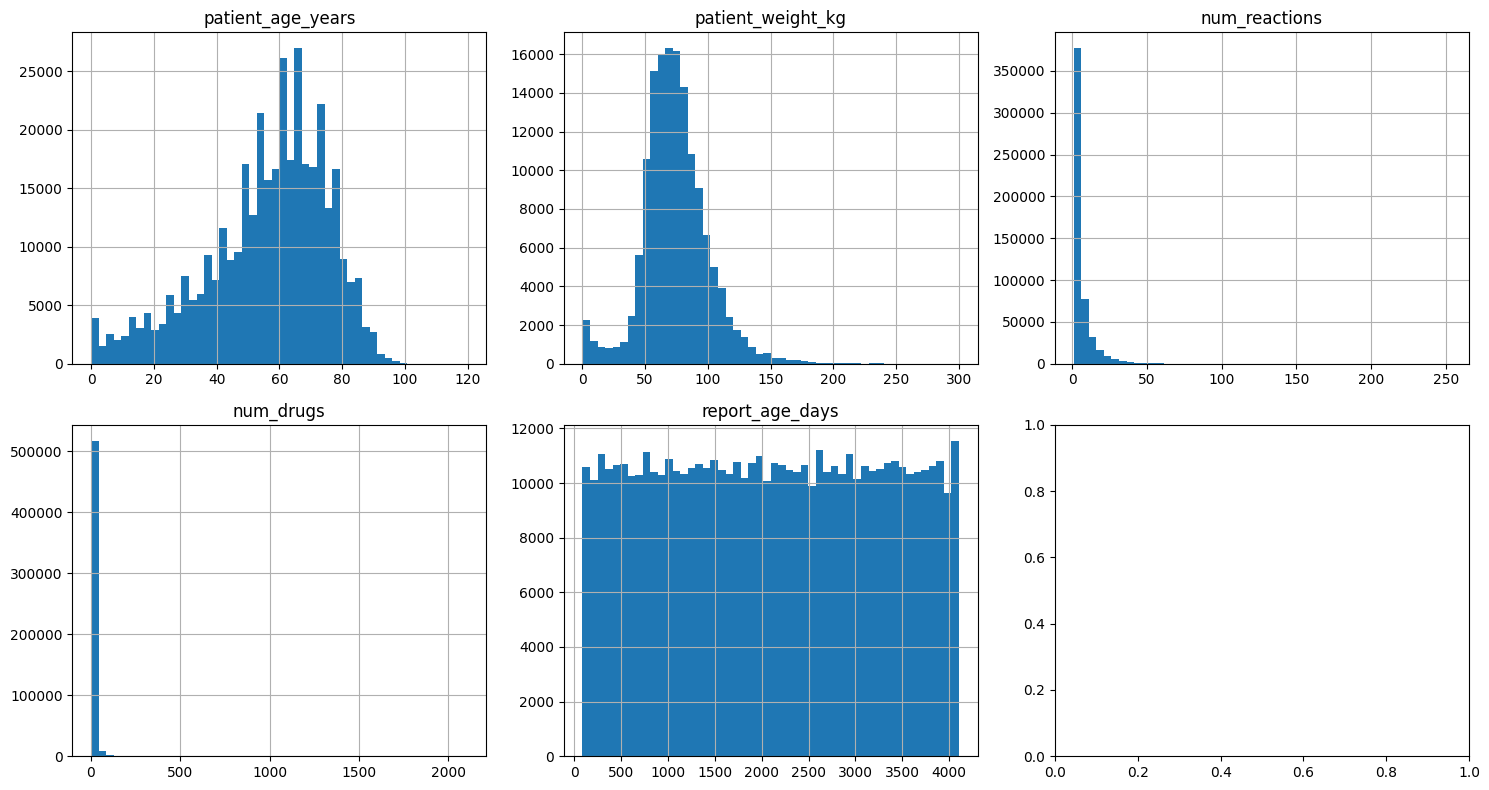

In [6]:
num_cols = ['patient_age_years', 'patient_weight_kg', 'num_reactions',
            'num_drugs', 'report_age_days']

print(df[num_cols].describe().T)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, col in enumerate(num_cols):
    df[col].dropna().hist(bins=50, ax=axes[i//3][i%3])
    axes[i//3][i%3].set_title(col)
plt.tight_layout()
plt.show()

The numerical features show a mix of reasonable clinical patterns and strong skewness/outliers.

`patient_age_years`  is centered around middle-to-older ages (mean ≈ 56, median ≈ 59), with most values between 45 and 70 years, and a valid range from 0 to 120.

`patient_weight_kg` is moderately right-skewed (mean ≈ 74 kg), concentrated between 59 and 88 kg, but includes extreme outliers up to 300 kg, which may require filtering or robust handling.

The `num_reactions` variable is highly skewed, where most reports contain few reactions (median = 4), but some extreme cases reach 253 reactions, indicating possible rare multi-event reports or data aggregation effects. Similarly,`num_drugs` is extremely skewed, with most cases involving a small number of drugs (median = 4), but with very large outliers up to 2108, which likely represent aggregated or erroneous entries and should be treated carefully (e.g., capping or log transformation).

Finally, `report_age_days` is widely distributed across the full time range (mean ≈ 2096 days), showing no clear concentration and suggesting continuous reporting over years.

## 5. Categorical Feature Distributions

In [7]:
cat_cols = ['age_group', 'patient_sex', 'drug_route', 'drug_count_category',
            'country', 'quarter']

for col in cat_cols:
    print(f"\n--- {col} ({df[col].nunique()} unique) ---")
    print(df[col].value_counts(dropna=False).head(10))


--- age_group (8 unique) ---
age_group
Middle-Aged(41-65)    166278
Unknown               152337
Senior(66-80)         108781
Adult(19-40)           53277
Elderly(81+)           25842
Child(3-12)             9767
Teen(13-18)             8617
Infant(0-2)             3101
Name: count, dtype: int64

--- patient_sex (3 unique) ---
patient_sex
Female     279155
Male       198932
Unknown     49913
Name: count, dtype: int64

--- drug_route (62 unique) ---
drug_route
48.0       196194
65.0        96762
Unknown     81843
58.0        56742
42.0        50284
41.0        10937
50.0         6258
30.0         5821
64.0         4484
55.0         3584
Name: count, dtype: int64

--- drug_count_category (5 unique) ---
drug_count_category
Polypharmacy(6+)    221528
2-3 Drugs           126066
Single              106633
4-5 Drugs            71972
Unknown               1801
Name: count, dtype: int64

--- country (162 unique) ---
country
US         317456
CA          54616
JP          25287
DE          1641

The `drug_route` column contains numeric codes (48.0, 65.0, 58.0) that correspond to FDA's official route-of-administration code list. These are legitimate identifiers, not mislabeled floats.

## 6.  High-Cardinality Text Columns

In [8]:
for col in ['suspect_drug', 'brand_name', 'drug_indication',
            'manufacturer', 'pharm_class', 'primary_reaction', 'reactions', 'country']:
    n = df[col].nunique()
    vc = df[col].value_counts(normalize=True).cumsum()
    n80 = (vc < 0.80).sum() + 1
    print(f"{col}: {n} unique | top-{n80} covers 80% of rows")

suspect_drug: 9828 unique | top-334 covers 80% of rows
brand_name: 2782 unique | top-225 covers 80% of rows
drug_indication: 5385 unique | top-123 covers 80% of rows
manufacturer: 1570 unique | top-73 covers 80% of rows
pharm_class: 448 unique | top-29 covers 80% of rows
primary_reaction: 10446 unique | top-804 covers 80% of rows
reactions: 371324 unique | top-265724 covers 80% of rows
country: 162 unique | top-5 covers 80% of rows


The high-cardinality categorical features show strong long-tail distributions. Variables such as `suspect_drug` **(9,828 unique)**, `brand_name` **(2,782 unique)**, `drug_indication` **(5,385 unique)**, `manufacturer` **(1,570 unique)**, and `primary_reaction` **(10,446 unique)** have relatively concentrated distributions where a small subset of categories covers most of the data (e.g., top 73–804 categories cover 80% of rows).

Even though `country` has only 162 unique values, it is still highly imbalanced, with the top 5 countries covering 80% of the data. Overall, these features are not suitable for naive encoding approaches and will require strategies such as frequency encoding, target encoding, or grouping rare categories into an “Other” class before modeling.

## 7. Outlier Inspection (Numeric)

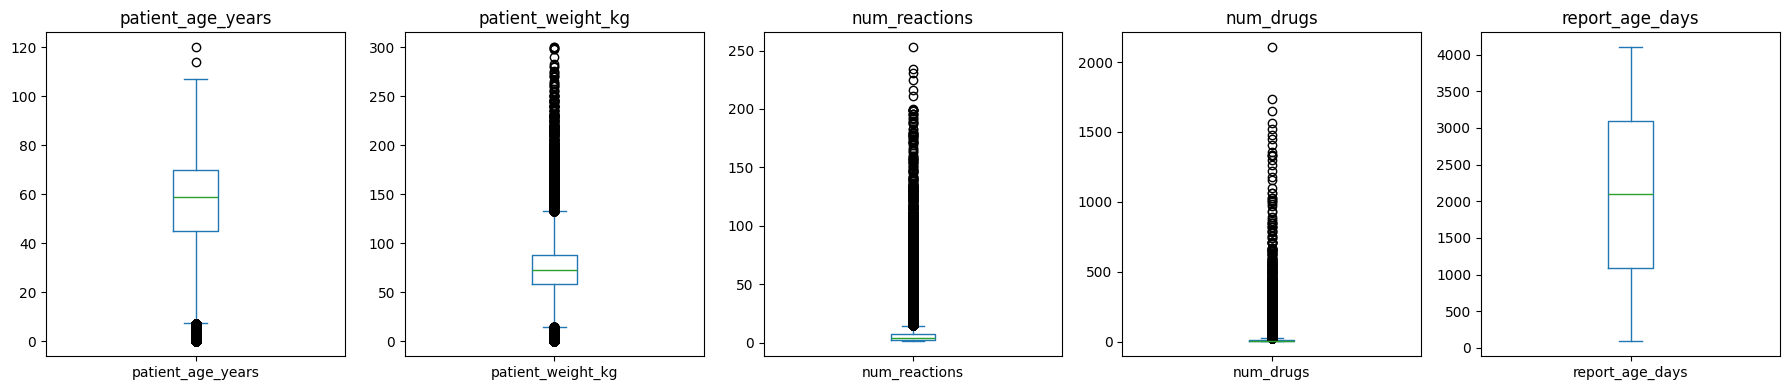

patient_age_years: 0 extreme outliers (0.00%)
patient_weight_kg: 463 extreme outliers (0.09%)
num_reactions: 22777 extreme outliers (4.31%)
num_drugs: 17873 extreme outliers (3.39%)
report_age_days: 0 extreme outliers (0.00%)


In [9]:
fig, axes = plt.subplots(1, len(num_cols), figsize=(18, 4))
for i, col in enumerate(num_cols):
    df[col].dropna().plot(kind='box', ax=axes[i], title=col)
plt.tight_layout()
plt.show()

# Quantify extreme values
for col in num_cols:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    extreme = ((df[col] < Q1 - 3*IQR) | (df[col] > Q3 + 3*IQR)).sum()
    print(f"{col}: {extreme} extreme outliers ({extreme/len(df)*100:.2f}%)")

The **boxplot and IQR-based analysis** show that most numerical features are relatively well-behaved, with no extreme outliers detected in `patient_age_years` and `report_age_days`.

However, `num_reactions` and `num_drugs` contain a noticeable proportion of extreme values (4.31% and 3.39% respectively), indicating heavy right skew and the presence of unusually large cases that may reflect either rare clinical scenarios or aggregated reporting effects.

The `patient_weight_kg` column shows a very small proportion of outliers (0.09%), suggesting only a few extreme values that are unlikely to significantly affect overall distribution. Overall, while most variables are stable, `num_reactions` and `num_drugs` require careful handling (such as capping or transformation) before being used in classification models to avoid bias from extreme values.


The 3×IQR method confirmed zero extreme outliers in `patient_age_years`, but the minimum value of 0.00 visible in the describe output (Step 4) warrants attention. Ages at or near zero likely represent infants reported in fractional years or days converted to years, which is clinically valid but behaviorally distinct from the adult-dominant distribution (mean 56, median 59). These edge cases won't be flagged as outliers by IQR but may still affect model performance and should be accounted for through the `age_group` feature, which already handles this with an Infant(0-2) bin.

## 8. Temporal Distribution

year
2015    48000
2016    48000
2017    48000
2018    48000
2019    48000
2020    48000
2021    48000
2022    48000
2023    48000
2024    48000
2025    48000
Name: count, dtype: int64
quarter
2015Q1    12000
2015Q2    12000
2015Q3    12000
2015Q4    12000
2016Q1    12000
2016Q2    12000
2016Q3    12000
2016Q4    12000
2017Q1    12000
2017Q2    12000
2017Q3    12000
2017Q4    12000
2018Q1    12000
2018Q2    12000
2018Q3    12000
2018Q4    12000
2019Q1    12000
2019Q2    12000
2019Q3    12000
2019Q4    12000
2020Q1    12000
2020Q2    12000
2020Q3    12000
2020Q4    12000
2021Q1    12000
2021Q2    12000
2021Q3    12000
2021Q4    12000
2022Q1    12000
2022Q2    12000
2022Q3    12000
2022Q4    12000
2023Q1    12000
2023Q2    12000
2023Q3    12000
2023Q4    12000
2024Q1    12000
2024Q2    12000
2024Q3    12000
2024Q4    12000
2025Q1    12000
2025Q2    12000
2025Q3    12000
2025Q4    12000
Name: count, dtype: int64
month
1     44000
2     44000
3     44000
4     44000
5     44000
6     44000

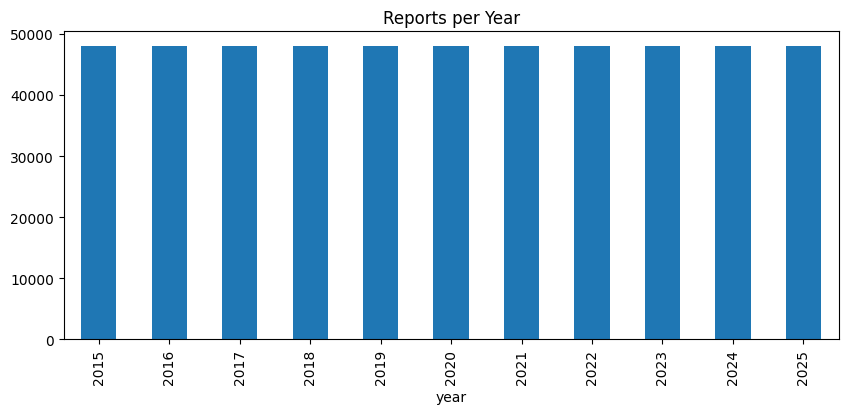

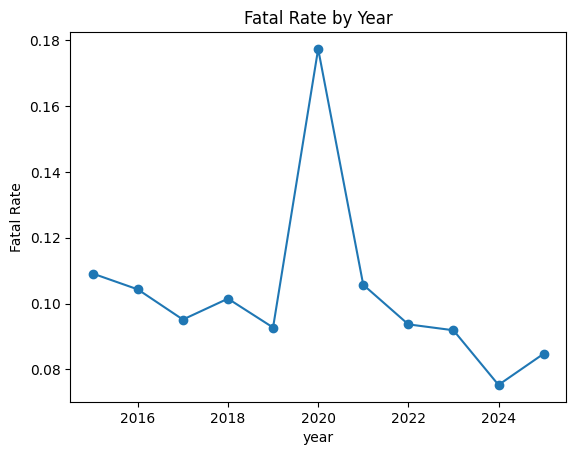

In [10]:
print(df['year'].value_counts().sort_index())
print(df['quarter'].value_counts().sort_index())
print(df['month'].value_counts().sort_index())

df['year'].value_counts().sort_index().plot(kind='bar', figsize=(10, 4))
plt.title('Reports per Year')
plt.show()

# Target rate over time
df.groupby('year')['is_fatal'].mean().plot(marker='o', title='Fatal Rate by Year')
plt.ylabel('Fatal Rate')
plt.show()

The dataset is perfectly balanced across time; exactly 48,000 reports per year (2015 - 2025) and exactly 12,000 per quarter, 44,000 per month. This is not natural FAERS behavior; it confirms the dataset was deliberately sampled or stratifid not a raw export.

**Two important implications follow from this:**

First, year, month, and quarter carry no volume signal; there is no reporting surge or decline to detect. Their value as features is limited to any outcome rate variation over time, not report frequency.

Second, the fatal rate plot shows meaningful variation; a sharp spike to ~0.18 in 2020 (likely COVID-19 related drug reporting), with rates otherwise ranging from ~0.08 to ~0.11. This means year does retain some predictive signal through outcome rate drift, but the uniform sampling means a random train/test split is acceptable here; there is no natural time-series dependency created by uneven sampling volumes.

## 9. Target Variable Distributions

In [11]:
for col in ['serious', 'is_fatal', 'is_hospitalized', 'is_life_threat', 'is_disabling', 'patient_recovered']:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))
    print(df[col].value_counts(normalize=True).round(3))


--- serious ---
serious
Yes    395000
No     133000
Name: count, dtype: int64
serious
Yes    0.748
No     0.252
Name: proportion, dtype: float64

--- is_fatal ---
is_fatal
False    473699
True      54301
Name: count, dtype: int64
is_fatal
False    0.897
True     0.103
Name: proportion, dtype: float64

--- is_hospitalized ---
is_hospitalized
False    339958
True     188042
Name: count, dtype: int64
is_hospitalized
False    0.644
True     0.356
Name: proportion, dtype: float64

--- is_life_threat ---
is_life_threat
False    505129
True      22871
Name: count, dtype: int64
is_life_threat
False    0.957
True     0.043
Name: proportion, dtype: float64

--- is_disabling ---
is_disabling
False    514476
True      13524
Name: count, dtype: int64
is_disabling
False    0.974
True     0.026
Name: proportion, dtype: float64

--- patient_recovered ---
patient_recovered
False    404545
True     123455
Name: count, dtype: int64
patient_recovered
False    0.766
True     0.234
Name: proportion, dtype:

`is_fatal` at 10.3% positive is a clinically significant and well-defined classification target. While more imbalanced than `is_hospitalized` (35.6%), fatality prediction is the highest-stakes outcome in pharmacovigilance. `serious` is skewed toward the positive class (74.8%), making it harder to learn meaningful separation. `is_life_threat` and `is_disabling` are severely imbalanced at 4.3% and 2.6% — predicting the majority class alone would achieve 95–97% accuracy, making accuracy a completely useless metric for these. `patient_recovered` represents a post-event outcome rather than an event severity predictor, making it clinically less meaningful as a target. Proceed with `is_fatal` as the primary target, using SMOTE to handle the class imbalance.


## 10. Target Overlap / Leakage Check

In [12]:
bool_targets = ['is_fatal', 'is_hospitalized', 'is_life_threat', 'is_disabling', 'patient_recovered']

# Crosstab each flag against 'serious'
for col in bool_targets:
    print(f"\nserious × {col}:")
    print(pd.crosstab(df['serious'], df[col], normalize='index').round(3))

# Overlap between flags
print(pd.crosstab(df['is_fatal'], df['is_hospitalized']))
print(df[bool_targets].sum())
print(df[bool_targets].corr().round(2))


serious × is_fatal:
is_fatal  False  True 
serious               
No        1.000  0.000
Yes       0.863  0.137

serious × is_hospitalized:
is_hospitalized  False  True 
serious                      
No               1.000  0.000
Yes              0.524  0.476

serious × is_life_threat:
is_life_threat  False  True 
serious                     
No              1.000  0.000
Yes             0.942  0.058

serious × is_disabling:
is_disabling  False  True 
serious                   
No            1.000  0.000
Yes           0.966  0.034

serious × patient_recovered:
patient_recovered  False  True 
serious                        
No                 0.869  0.131
Yes                0.732  0.268
is_hospitalized   False   True 
is_fatal                       
False            313652  160047
True              26306   27995
is_fatal              54301
is_hospitalized      188042
is_life_threat        22871
is_disabling          13524
patient_recovered    123455
dtype: int64
                   is_fa

This is the most critical finding in the entire EDA. The crosstabs confirm a hard rule: every non-serious case (serious = No) has a 0.0% rate on all four flags; no non-serious case is ever fatal, hospitalized, life-threatening, or disabling. This means the flags are definitional components of serious, not independent observations.

Concretely: if our target is `is_fatal`, then `serious`, `serious_flags`, `reaction_outcomes`, `is_hospitalized`, `is_life_threat`, `is_disabling`, and `patient_recovered` are all leakage and must be excluded as features; the model would trivially learn that serious=No always means is_fatal=False.

The inter-flag correlations are low (0.01 - 0.17), confirming the flags are largely independent of each other; a case can be **fatal** without being hospitalized and vice versa. patient_recovered shows a negative correlation with `is_fatal` (-0.08) and a positive correlation with `is_hospitalized` (0.22), which is directionally sensible clinically but still constitutes leakage since recovery is a downstream outcome.

## 11. Serious_flags & Reaction_outcomes String Inspection

In [13]:
print(df['serious_flags'].value_counts(dropna=False).head(20))
print(df['reaction_outcomes'].value_counts(dropna=False).head(20))

# Check if multi-value (pipe/comma separated)
print(df['serious_flags'].dropna().str.contains('[|,;]', regex=True).sum())
print(df['reaction_outcomes'].dropna().str.contains('[|,;]', regex=True).sum())

serious_flags
NaN                                                                         301106
Hospitalization                                                             142536
Death                                                                        24407
Death; Hospitalization                                                       22828
Hospitalization; Life-Threatening                                            11163
Disability                                                                    5763
Hospitalization; Disability                                                   4544
Life-Threatening                                                              4309
Death; Hospitalization; Life-Threatening                                      3795
Congenital Anomaly                                                            2051
Death; Life-Threatening                                                       1242
Hospitalization; Life-Threatening; Disability                            

`serious_flags` is a semicolon-delimited multi-label string that directly encodes the boolean flags; "Death; Hospitalization" is exactly what `is_fatal`=True and `is_hospitalized`=True together represent. It provides zero additional information beyond what the boolean columns already capture and has 57% missingness. It should be excluded entirely as a feature regardless of target choice.

`reaction_outcomes` is similarly a delimited string encoding recovery status across multiple reactions. With 230,688 rows containing multi-value entries (vs only 47,828 in serious_flags), it is far more complex.

The dominant value being Unknown (200,782 rows, ~38%) indicates substantial reporting incompleteness. The presence of Fatal as a value in `reaction_outcomes` makes it direct leakage if predicting `is_fatal` or `is_hospitalized`. This column should also be excluded as a feature.

## 12. Reactions & Primary_reaction Inspection

In [14]:
print(df['primary_reaction'].value_counts().head(30))
print(df['reactions'].dropna().head(10))

# Multi-value check
print("Multi-reaction rows:", df['reactions'].str.contains('[|,;/]', regex=True, na=False).sum())

# Avg reactions encoded in the string vs num_reactions column
df['reactions'].dropna().str.split('[|,;]', regex=True).str.len().describe()

primary_reaction
Drug ineffective                10437
Death                            9371
Pneumonia                        5510
Drug hypersensitivity            5492
Myocardial infarction            5317
Gynaecomastia                    5153
Chronic kidney disease           5083
Off label use                    4934
Gastrointestinal haemorrhage     4802
Cerebrovascular accident         4096
Fatigue                          4044
Acute kidney injury              3827
Pain                             3603
Diarrhoea                        3480
Dyspnoea                         3135
Nausea                           3090
Malaise                          2971
Headache                         2940
Renal injury                     2849
Fall                             2831
Condition aggravated             2817
Alopecia                         2682
COVID-19                         2566
Arthralgia                       2485
Crohn^s disease                  2407
Cardiac failure congestive       

count    528000.000000
mean          3.347939
std           1.611658
min           1.000000
25%           2.000000
50%           4.000000
75%           5.000000
max           9.000000
Name: reactions, dtype: float64

`primary_reaction` covers a clinically diverse range; from outcome-level terms (Death, Myocardial infarction) to symptoms (Fatigue, Nausea) and conditions (COVID-19, Chronic kidney disease)

`reactions` is a semicolon-delimited multi-value field with 80% of rows containing multiple entries; unusable as-is. Its parsed length (mean 3.35) diverges from `num_reactions` (mean 6.28), suggesting the string was capped during dataset construction while num_reactions reflects the true count. Prefer `num_reactions` for reaction burden; the raw string should be dropped or processed separately.

Critical leakage flag: `Death` appearing as a primary_reaction value (9,371 rows) is direct target leakage if `is_fatal` is the outcome. This column needs explicit handling before any encoding.

## 13. Pharm_class & Drug_indication Inspection

In [15]:
print(df['pharm_class'].value_counts(dropna=False).head(20))
print(df['drug_indication'].value_counts(dropna=False).head(20))

# Missing rate by target
for col in ['pharm_class', 'drug_indication']:
    print(f"\nMissing {col} by is_fatal:")
    print(df.groupby('is_fatal')[col].apply(lambda x: x.isnull().mean()).round(3))

pharm_class
Unknown                                                235513
Tumor Necrosis Factor Blocker [EPC]                     27036
Atypical Antipsychotic [EPC]                            19268
Factor Xa Inhibitor [EPC]                               13839
Kinase Inhibitor [EPC]                                  12482
Integrin Receptor Antagonist [EPC]                      11087
CD20-directed Cytolytic Antibody [EPC]                   9955
Interleukin-4 Receptor alpha Antagonist [EPC]            8246
Programmed Death Receptor-1 Blocking Antibody [EPC]      7895
Endothelin Receptor Antagonist [EPC]                     7331
Interleukin-17A Antagonist [EPC]                         6144
Corticosteroid [EPC]                                     5836
Thalidomide Analog [EPC]                                 5561
Androgen Receptor Inhibitor [EPC]                        4377
Nonsteroidal Anti-inflammatory Drug [EPC]                3931
Insulin Analog [EPC]                                     3

Neither `pharm_class` nor `drug_indication` has true null values, but both use placeholder strings; "Unknown" and "Product Used For Unknown Indication"; as masked missingness. These account for ~235K unknowns in pharm_class (4.6%) and ~134K in drug_indication (25.3%), and must be treated as missing during preprocessing.

Since missingness rates are identical across outcome classes, there's no signal in null patterns alone; but the Unknown string distribution between fatal and non-fatal cases is still worth checking.

`pharm_class`is the more tractable feature: 448 unique values, top 29 covering 80% of rows, dominated by structured FDA EPC terms (e.g. Tumor Necrosis Factor Blocker, Atypical Antipsychotic). `drug_indication` is messier at 5,385 unique values and will need **top-N bucketing** before encoding.

## 14. Correlation Matrix

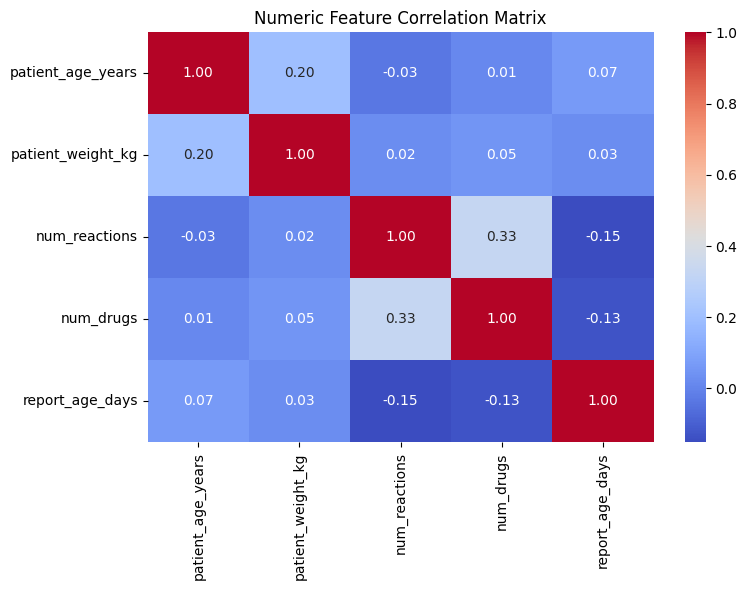

In [16]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Numeric Feature Correlation Matrix')
plt.tight_layout()
plt.show()

All numeric features are weakly correlated; no multicollinearity concerns. The strongest pair is `num_reactions` × `num_drugs` (r = 0.33), which is clinically expected and moderate enough that both carry independent signal. `patient_age_years` × `patient_weight_kg` (r = 0.20) reflects normal demographic patterns.


All other pairs are near zero (−0.15 to 0.07). The small negative correlations between `report_age_days` and both `num_reactions/num_drugs` (r ≈ −0.14) likely reflect incomplete multi-drug reporting in earlier FAERS years rather than any clinical pattern.

# EDA - Preprocessing Decision Summary

In [17]:
# @title
from IPython.display import HTML

html = """
<style>
  @import url('https://fonts.googleapis.com/css2?family=IBM+Plex+Mono:wght@400;500&family=Syne:wght@400;500;600;700&display=swap');

  .eda-wrapper {
    font-family: 'Syne', sans-serif;
    background: #0D0F14;
    border-radius: 16px;
    padding: 32px 36px 40px;
    margin: 16px 0;
    box-shadow: 0 0 0 1px rgba(255,255,255,0.07), 0 24px 60px rgba(0,0,0,0.6);
  }

  .eda-header {
    display: flex;
    align-items: baseline;
    gap: 14px;
    margin-bottom: 28px;
    border-bottom: 1px solid rgba(255,255,255,0.08);
    padding-bottom: 18px;
  }

  .eda-title {
    font-size: 20px;
    font-weight: 700;
    color: #F2F2F2;
    letter-spacing: -0.02em;
    margin: 0;
  }

  .eda-subtitle {
    font-size: 12px;
    font-weight: 500;
    color: #5A5F70;
    text-transform: uppercase;
    letter-spacing: 0.1em;
    margin: 0;
  }

  .eda-table {
    width: 100%;
    border-collapse: separate;
    border-spacing: 0;
    font-size: 13px;
    table-layout: fixed;
  }

  .eda-table col:nth-child(1) { width: 25%; }
  .eda-table col:nth-child(2) { width: 20%; }
  .eda-table col:nth-child(3) { width: 55%; }

  .eda-table thead th {
    font-family: 'IBM Plex Mono', monospace;
    font-size: 10px;
    font-weight: 500;
    text-transform: uppercase;
    letter-spacing: 0.12em;
    color: #4A5068;
    padding: 0 14px 10px;
    text-align: left;
  }

  .eda-table tbody tr.data-row {
    transition: background 0.15s;
  }

  .eda-table tbody tr.data-row:hover td {
    background: rgba(255,255,255,0.03);
  }

  .eda-table tbody tr.data-row td {
    padding: 10px 14px;
    vertical-align: top;
    color: #C8CCDA;
    line-height: 1.55;
    border-top: 1px solid rgba(255,255,255,0.04);
    word-break: break-word;
  }

  .eda-table tbody tr.data-row td:first-child {
    font-family: 'IBM Plex Mono', monospace;
    font-size: 11.5px;
    color: #7A8099;
  }

  .group-row td {
    padding: 20px 14px 6px !important;
    font-family: 'IBM Plex Mono', monospace !important;
    font-size: 10px !important;
    font-weight: 500 !important;
    text-transform: uppercase;
    letter-spacing: 0.12em;
    color: #3D4255 !important;
    border-top: none !important;
  }

  .group-row:first-child td {
    padding-top: 8px !important;
  }

  /* Badges */
  .badge {
    display: inline-block;
    font-family: 'IBM Plex Mono', monospace;
    font-size: 10.5px;
    font-weight: 500;
    padding: 3px 9px;
    border-radius: 5px;
    white-space: nowrap;
    letter-spacing: 0.02em;
  }

  .badge-drop    { background: rgba(220, 60, 60, 0.15); color: #E87070; border: 1px solid rgba(220,60,60,0.25); }
  .badge-keep    { background: rgba(70, 190, 100, 0.12); color: #6ED98A; border: 1px solid rgba(70,190,100,0.22); }
  .badge-encode  { background: rgba(60, 140, 255, 0.12); color: #72AEFF; border: 1px solid rgba(60,140,255,0.22); }
  .badge-caution { background: rgba(250, 170, 40, 0.12); color: #F5C25C; border: 1px solid rgba(250,170,40,0.22); }
  .badge-target  { background: rgba(170, 100, 255, 0.14); color: #C48FFF; border: 1px solid rgba(170,100,255,0.25); }

  .note-text { color: #5A6080; font-size: 12px; margin-top: 20px; padding-top: 16px; border-top: 1px solid rgba(255,255,255,0.06); font-family: 'IBM Plex Mono', monospace; }
</style>

<div class='eda-wrapper'>
  <div class='eda-header'>
    <p class='eda-title'>Preprocessing Decision Summary</p>
    <p class='eda-subtitle'>EDA Output</p>
  </div>

  <table class='eda-table'>
    <colgroup><col/><col/><col/></colgroup>
    <thead>
      <tr>
        <th>Column(s)</th>
        <th>Decision</th>
        <th>Reason</th>
      </tr>
    </thead>
    <tbody>

      <!-- Target & leakage -->
      <tr class='group-row'><td colspan='3'>Target &amp; Leakage</td></tr>
      <tr class='data-row'>
        <td>is_fatal</td>
        <td><span class='badge badge-target'>Target</span></td>
        <td>10.3% positive — highest-stakes outcome in pharmacovigilance; selected as primary target</td>
      </tr>
      <tr class='data-row'>
        <td>serious, serious_flags, reaction_outcomes, is_hospitalized, is_life_threat, is_disabling, patient_recovered</td>
        <td><span class='badge badge-drop'>Drop as features</span></td>
        <td>Direct leakage — all derive from or encode the target</td>
      </tr>

      <!-- Reaction columns -->
      <tr class='group-row'><td colspan='3'>Reaction Columns</td></tr>
      <tr class='data-row'>
        <td>primary_reaction</td>
        <td><span class='badge badge-encode'>Top-N + Other</span></td>
        <td>10,446 unique; top 804 cover 80% — needs reduction before encoding. "Death" term is leakage if predicting is_fatal</td>
      </tr>
      <tr class='data-row'>
        <td>reactions</td>
        <td><span class='badge badge-caution'>Drop or encode separately</span></td>
        <td>Multi-value semicolon string; misaligns with num_reactions count; contains leakage terms</td>
      </tr>
      <tr class='data-row'>
        <td>num_reactions</td>
        <td><span class='badge badge-keep'>Keep</span></td>
        <td>More reliable count than reactions string; independent signal; cap 4.31% extreme outliers</td>
      </tr>

      <!-- Drug columns -->
      <tr class='group-row'><td colspan='3'>Drug Columns</td></tr>
      <tr class='data-row'>
        <td>suspect_drug, brand_name</td>
        <td><span class='badge badge-encode'>Target encoding or drop</span></td>
        <td>Near-duplicate pair (brand vs generic); 9,828 and 2,782 unique values — too high for OHE</td>
      </tr>
      <tr class='data-row'>
        <td>drug_route</td>
        <td><span class='badge badge-encode'>Encode as nominal</span></td>
        <td>FDA numeric codes — not broken. Treat as nominal category; map to labels only if data dictionary is available</td>
      </tr>
      <tr class='data-row'>
        <td>drug_indication</td>
        <td><span class='badge badge-encode'>Top-N + Other</span></td>
        <td>5,385 unique; ~25% masked missing ("Unknown") — replace string unknowns with NaN first</td>
      </tr>
      <tr class='data-row'>
        <td>pharm_class</td>
        <td><span class='badge badge-encode'>Top-N + Other</span></td>
        <td>448 unique; top 29 cover 80% — most tractable high-value drug feature. ~44% masked missing ("Unknown")</td>
      </tr>
      <tr class='data-row'>
        <td>num_drugs</td>
        <td><span class='badge badge-keep'>Keep</span></td>
        <td>Independent signal; moderate correlation with num_reactions (0.33) — not redundant. Cap 3.39% outliers</td>
      </tr>
      <tr class='data-row'>
        <td>drug_count_category</td>
        <td><span class='badge badge-drop'>Drop</span></td>
        <td>Binned version of num_drugs — redundant pair; keep numeric column</td>
      </tr>
      <tr class='data-row'>
        <td>manufacturer</td>
        <td><span class='badge badge-encode'>Top-N + Other</span></td>
        <td>1,570 unique; top 73 cover 80%</td>
      </tr>

      <!-- Patient columns -->
      <tr class='group-row'><td colspan='3'>Patient Columns</td></tr>
      <tr class='data-row'>
        <td>patient_age_years</td>
        <td><span class='badge badge-caution'>Keep or drop (pick one)</span></td>
        <td>28.7% missing; redundant with age_group — keep age_group if missingness is a concern</td>
      </tr>
      <tr class='data-row'>
        <td>age_group</td>
        <td><span class='badge badge-keep'>Keep (preferred)</span></td>
        <td>Handles infant edge cases cleanly; no missingness; ordinal encoding applicable</td>
      </tr>
      <tr class='data-row'>
        <td>patient_sex</td>
        <td><span class='badge badge-encode'>Encode</span></td>
        <td>3 values (Female / Male / Unknown) — simple label or ordinal encoding</td>
      </tr>
      <tr class='data-row'>
        <td>patient_weight_kg</td>
        <td><span class='badge badge-drop'>Drop or flag only</span></td>
        <td>71.96% missing — too sparse for reliable imputation; consider binary missingness flag</td>
      </tr>

      <!-- Temporal columns -->
      <tr class='group-row'><td colspan='3'>Temporal Columns</td></tr>
      <tr class='data-row'>
        <td>year</td>
        <td><span class='badge badge-caution'>Keep with caution</span></td>
        <td>Uniform sampling removes volume signal; retains outcome drift signal (fatal rate varies 0.08–0.18)</td>
      </tr>
      <tr class='data-row'>
        <td>month, quarter</td>
        <td><span class='badge badge-drop'>Drop</span></td>
        <td>Perfectly uniform sampling — zero signal in either volume or outcome rate</td>
      </tr>
      <tr class='data-row'>
        <td>receive_date</td>
        <td><span class='badge badge-drop'>Drop</span></td>
        <td>year already captures temporal information; raw date adds no further signal</td>
      </tr>
      <tr class='data-row'>
        <td>report_age_days</td>
        <td><span class='badge badge-keep'>Keep</span></td>
        <td>No outliers; independent of other features; small but clean negative correlation with drug/reaction counts</td>
      </tr>

      <!-- Geography -->
      <tr class='group-row'><td colspan='3'>Geography</td></tr>
      <tr class='data-row'>
        <td>country</td>
        <td><span class='badge badge-encode'>Top-N + Other</span></td>
        <td>162 unique; top 5 cover 80% — heavily US-dominated; group remainder into "Other"</td>
      </tr>

    </tbody>
  </table>

  <p class='note-text'>// 5 groups &nbsp;·&nbsp; 24 columns reviewed &nbsp;·&nbsp; target: is_fatal</p>
</div>
"""

HTML(html)

# II. Preprocessing

Pipeline order:
1. Drop leakage columns
2. Drop redundant and non-informative columns
3. Confirm target and drop rows with missing target
4. Fix masked missingness (placeholder strings to NaN)
5. Cap numeric outliers
6. Remove leakage term from primary_reaction
7. Feature Engineering (on clean raw columns before encoding)
8. Encode categoricals
9. Train / Test Split
10. Feature Scaling (continuous columns only)
11. SMOTE on training set only

## Step 1 - Drop Leakage Columns

The following columns are definitional components of `is_fatal` or are downstream outcomes.
EDA confirmed that every non-serious row has a 0% rate on all boolean flags, meaning these columns
trivially reveal the target. They must be removed before any modeling.

In [18]:
LEAKAGE_COLS = [
    'serious',
    'serious_flags',
    'reaction_outcomes',
    'is_hospitalized',
    'is_life_threat',
    'is_disabling',
    'patient_recovered',
]

df_clean = df.copy()
df_clean.drop(columns=LEAKAGE_COLS, inplace=True, errors='ignore')

print(f"Shape before: {df.shape}")
print(f"Shape after dropping leakage columns: {df_clean.shape}")
print(f"Columns remaining: {df_clean.columns.tolist()}")

Shape before: (528000, 30)
Shape after dropping leakage columns: (528000, 23)
Columns remaining: ['report_id', 'receive_date', 'year', 'month', 'quarter', 'is_fatal', 'reactions', 'primary_reaction', 'num_reactions', 'suspect_drug', 'brand_name', 'drug_route', 'drug_indication', 'manufacturer', 'pharm_class', 'num_drugs', 'drug_count_category', 'patient_age_years', 'age_group', 'patient_sex', 'patient_weight_kg', 'country', 'report_age_days']


## Step 2 - Drop Redundant and Non-Informative Columns

| Column | Reason for Dropping |
|---|---|
| report_id | Unique identifier with no predictive signal |
| receive_date | Temporal signal is already captured by year |
| month | EDA confirmed perfectly uniform sampling across months |
| quarter | Same reason as month |
| drug_count_category | Binned duplicate of num_drugs |
| patient_weight_kg | 71.96% missing, too sparse for reliable imputation |
| reactions | Raw semicolon string; num_reactions captures this cleanly |
| patient_age_years | 28.69% missing; age_group has no missing values |
| brand_name | Only 1.3% exact match with suspect_drug and adds noise |

In [19]:
DROP_COLS = [
    'report_id',
    'receive_date',
    'month',
    'quarter',
    'drug_count_category',
    'patient_weight_kg',
    'reactions',
    'patient_age_years',
    'brand_name',
]

df_clean.drop(columns=DROP_COLS, inplace=True, errors='ignore')

print(f"Shape after dropping redundant columns: {df_clean.shape}")
print(f"Remaining columns ({len(df_clean.columns)}):")
for c in df_clean.columns:
    print(f"  {c}")

Shape after dropping redundant columns: (528000, 14)
Remaining columns (14):
  year
  is_fatal
  primary_reaction
  num_reactions
  suspect_drug
  drug_route
  drug_indication
  manufacturer
  pharm_class
  num_drugs
  age_group
  patient_sex
  country
  report_age_days


## Step 3 - Confirm Target and Drop Missing Target Rows

The target variable is `is_fatal`. Any row where the target is NaN must be removed
before modeling. We also confirm the class distribution.

In [20]:
TARGET = 'is_fatal'

before = len(df_clean)
df_clean.dropna(subset=[TARGET], inplace=True)
dropped = before - len(df_clean)

print(f"Rows dropped due to missing target: {dropped}")
print(f"Shape after target check: {df_clean.shape}")
print("=" * 50)
print("Target distribution:")
print(df_clean[TARGET].value_counts())
print("=" * 50)
print("Target distribution (normalized):")
print(df_clean[TARGET].value_counts(normalize=True).round(4))

Rows dropped due to missing target: 0
Shape after target check: (528000, 14)
Target distribution:
is_fatal
False    473699
True      54301
Name: count, dtype: int64
Target distribution (normalized):
is_fatal
False    0.8972
True     0.1028
Name: proportion, dtype: float64


## Step 4 - Fix Masked Missingness

EDA Step 13 confirmed that `pharm_class` and `drug_indication` use placeholder strings
instead of true NaN. `drug_route` also contains a literal 'Unknown' string.
These must be replaced with actual NaN values so that imputation and encoding
handle them correctly.

In [21]:
MASKED_MISSING = {
    'pharm_class':     ['Unknown'],
    'drug_indication': ['Unknown', 'Product Used For Unknown Indication'],
    'drug_route':      ['Unknown'],
}

print("Replacing masked missing values with NaN:")
for col, placeholders in MASKED_MISSING.items():
    if col in df_clean.columns:
        before_count = df_clean[col].isnull().sum()
        df_clean[col] = df_clean[col].replace(placeholders, np.nan)
        after_count = df_clean[col].isnull().sum()
        print(f"  {col}:\n {before_count:,} nulls before  \n{after_count:,} nulls after  (+{after_count - before_count:,})")
        print()

print()
missing_now = df_clean.isnull().sum()
print("Current missing value counts:")
print(missing_now[missing_now > 0].sort_values(ascending=False))

Replacing masked missing values with NaN:
  pharm_class:
 0 nulls before  
235,513 nulls after  (+235,513)

  drug_indication:
 0 nulls before  
133,632 nulls after  (+133,632)

  drug_route:
 0 nulls before  
81,843 nulls after  (+81,843)


Current missing value counts:
pharm_class        235513
drug_indication    133632
drug_route          81843
dtype: int64


## Step 5 - Cap Numeric Outliers

EDA Step 7 identified extreme outliers in `num_reactions` (max=253, 4.31% extreme)
and `num_drugs` (max=2108, 3.39% extreme). Capping at the 99th percentile
preserves all rows while eliminating absurd extremes that could distort model learning.

In [22]:
def cap_outliers(df, col, percentile=99):
    cap_value = df[col].quantile(percentile / 100)
    n_capped = (df[col] > cap_value).sum()
    df[col] = df[col].clip(upper=cap_value)
    print(f"  {col}: cap value = {cap_value:.1f} | rows capped = {n_capped:,} ({n_capped / len(df) * 100:.2f}%)")
    return df

print("Capping outliers at 99th percentile:")
for col in ['num_reactions', 'num_drugs']:
    df_clean = cap_outliers(df_clean, col)

print()
print("Post-capping stats:")
print(df_clean[['num_reactions', 'num_drugs']].describe().round(2))

Capping outliers at 99th percentile:
  num_reactions: cap value = 41.0 | rows capped = 5,006 (0.95%)
  num_drugs: cap value = 59.0 | rows capped = 5,225 (0.99%)

Post-capping stats:
       num_reactions  num_drugs
count      528000.00  528000.00
mean            6.11       8.07
std             7.15      10.20
min             1.00       1.00
25%             2.00       2.00
50%             4.00       4.00
75%             7.00      10.00
max            41.00      59.00


## Step 6 - Remove Leakage Term from primary_reaction

EDA Step 12 identified 'Death' appearing 9,371 times in `primary_reaction`.
This is a direct target leakage term because it encodes a fatal outcome.
We replace it with NaN, which will be handled during frequency encoding.

In [23]:
if 'primary_reaction' in df_clean.columns:
    death_mask = df_clean['primary_reaction'].str.contains('death', case=False, na=False)
    n_death_related = death_mask.sum()
    df_clean.loc[death_mask, 'primary_reaction'] = np.nan
    print(f"Replaced {n_death_related:,} entries containing 'death' with NaN")

print(f"Shape after preprocessing clean-up: {df_clean.shape}")
print()
missing_after = df_clean.isnull().sum()
print("Missing value summary:")
print(missing_after[missing_after > 0].sort_values(ascending=False))

Replaced 10,013 entries containing 'death' with NaN
Shape after preprocessing clean-up: (528000, 14)

Missing value summary:
pharm_class         235513
drug_indication     133632
drug_route           81843
primary_reaction     10013
dtype: int64


# III. Feature Engineering

Feature engineering runs on cleaned raw columns before any encoding.
All derived features are computed on the full dataset before the train/test split.
This is correct because these are transformations of existing columns,
not statistics fitted on data, so there is no leakage.

New features target fatality risk specifically, guided by EDA insights.

## FE 1 - is_elderly_polypharmacy

Elderly and Senior patients on 6 or more drugs face compounded risk.
Aging reduces drug metabolism efficiency, and polypharmacy multiplies
drug interaction probability. Neither factor alone captures this combined profile.

In [24]:
ELDERLY_LABELS = {'Elderly(81+)', 'Senior(66-80)'}

df_clean['is_elderly_polypharmacy'] = (
    df_clean['age_group'].isin(ELDERLY_LABELS) & (df_clean['num_drugs'] >= 6)
).astype(int)

print("is_elderly_polypharmacy distribution:")
print(df_clean['is_elderly_polypharmacy'].value_counts())
print()
fatal_rate = df_clean.groupby('is_elderly_polypharmacy')[TARGET].mean().round(4)
print(f"Fatal rate by group: {fatal_rate.to_dict()}")

is_elderly_polypharmacy distribution:
is_elderly_polypharmacy
0    464717
1     63283
Name: count, dtype: int64

Fatal rate by group: {0: 0.092, 1: 0.1827}


## FE 2 - is_high_risk_route

The following codes were selected to build the is_high_risk_route feature, representing administration methods with the highest clinical impact and potential for fatal outcomes:

| FDA Code | Route Name | Clinical Significance |
|---------|------------|----------------------|
| 65 | Intravenous (IV) | Direct systemic delivery; bypasses all protective barriers. |
| 42 | Intramuscular (IM) | Rapid absorption through highly vascularized muscle tissue. |
| 13 | Intrathecal | Injected into the spinal canal; direct access to the CNS. |
| 7  | Intracardiac | Emergency route; injected directly into the heart chambers. |
| 6  | Intra-arterial | Direct delivery into an artery; affects specific organs at high concentration. |
| 10 | Intracerebral | Injected directly into brain tissue; extreme risk level. |
| 51 | Respiratory | High lung surface area → near-instant blood absorption. |
| 12 | Intraspinal | Delivery into the spinal column; bypasses the blood-brain barrier. |

In [25]:
HIGH_RISK_ROUTE_CODES = {65, 42, 13, 6, 7, 10, 51, 12} 

route_numeric = pd.to_numeric(df_clean['drug_route'], errors='coerce')
df_clean['is_high_risk_route'] = route_numeric.isin(HIGH_RISK_ROUTE_CODES).astype(int)

print("is_high_risk_route distribution:")
print(df_clean['is_high_risk_route'].value_counts())
print()
fatal_rate = df_clean.groupby('is_high_risk_route')[TARGET].mean().round(4)
print(f"Fatal rate by group: {fatal_rate.to_dict()}")

route_stats = df_clean.groupby('drug_route')[TARGET].mean().sort_values(ascending=False)

is_high_risk_route distribution:
is_high_risk_route
0    380196
1    147804
Name: count, dtype: int64

Fatal rate by group: {0: 0.0981, 1: 0.1151}


## FE 3 - is_polypharmacy_high

This feature identifies patients taking **six or more concurrent medications**, a clinical threshold known as "Major Polypharmacy."

### Rationale:
* **Exponential Interactions:** As the number of drugs increases, the risk of adverse Drug-Drug Interactions (DDI) grows exponentially rather than linearly. 
* **Metabolic Overload:** Managing 6+ medications places significant stress on hepatic and renal clearance mechanisms, reducing the patient's ability to recover from toxicities.
* **Patient Complexity:** High polypharmacy is a proxy for "Multimorbidity" (patients with multiple chronic conditions), which is a known independent risk factor for fatal outcomes in the FAERS database.

In [26]:
df_clean['is_polypharmacy_high'] = (df_clean['num_drugs'] >= 6).astype(int)

print("is_polypharmacy_high distribution:")
print(df_clean['is_polypharmacy_high'].value_counts())
print()
fatal_rate = df_clean.groupby('is_polypharmacy_high')[TARGET].mean().round(4)
print(f"Fatal rate by group: {fatal_rate.to_dict()}")

is_polypharmacy_high distribution:
is_polypharmacy_high
0    304671
1    223329
Name: count, dtype: int64

Fatal rate by group: {0: 0.0958, 1: 0.1125}


## FE 4 - is_multi_reaction

This feature identifies cases with **more than three simultaneous adverse reactions**, serving as a proxy for systemic toxicity.

### Rationale:
* **Systemic vs. Localized:** While a single reaction (e.g., nausea) is often manageable, 4+ reactions typically indicate "Systemic Drug Toxicity" affecting multiple organ systems.
* **Severity Indicator:** In clinical toxicology, multi-organ involvement is a hallmark of life-threatening syndromes such as Anaphylaxis or SJS/TEN.
* **Predictive Power:** Engineering this feature allows the model to capture the "intensity" of the adverse event, which is strongly correlated with fatal outcomes in the FAERS dataset.

In [27]:
df_clean['is_multi_reaction'] = (df_clean['num_reactions'] > 3).astype(int)

print("is_multi_reaction distribution:")
print(df_clean['is_multi_reaction'].value_counts())
print()
fatal_rate = df_clean.groupby('is_multi_reaction')[TARGET].mean().round(4)
print(f"Fatal rate by group: {fatal_rate.to_dict()}")

is_multi_reaction distribution:
is_multi_reaction
1    266724
0    261276
Name: count, dtype: int64

Fatal rate by group: {0: 0.1121, 1: 0.0938}


## FE 5 - reaction_drug_ratio

This feature calculates the number of adverse reactions relative to the number of drugs consumed. It acts as a measure of **Systemic Drug Intolerance**.

### Rationale:
* **Toxicity Intensity:** A high ratio (many reactions for few drugs) suggests an acute, violent immune response or severe organ toxicity from a specific substance.
* **Normalization:** It helps the model differentiate between a "Polypharmacy" case (where many reactions might be expected) and a "High Sensitivity" case (where one drug causes total system failure).
* **Predictive Value:** Patients with a high reaction-to-drug ratio are clinically more unstable and show a higher correlation with `is_fatal` outcomes in the FAERS database.

In [28]:
df_clean['reaction_drug_ratio'] = (
    df_clean['num_reactions'] / df_clean['num_drugs'].replace({0: 1})
).round(4)

print("reaction_drug_ratio stats:")
print(df_clean['reaction_drug_ratio'].describe().round(4))
print()
corr = df_clean['reaction_drug_ratio'].corr(df_clean[TARGET])
print(f"Correlation with {TARGET}: {corr:.4f}")

reaction_drug_ratio stats:
count    528000.0000
mean          1.5743
std           2.2794
min           0.0169
25%           0.4000
50%           1.0000
75%           2.0000
max          41.0000
Name: reaction_drug_ratio, dtype: float64

Correlation with is_fatal: -0.0260


## FE 6 - is_covid_year

This feature flags records from the year **2020** to account for the statistical anomaly identified during EDA (Step 8), where fatality rates spiked to nearly **18%**.

### Rationale:
* **Isolating the Anomaly:** 2020 was an outlier due to the global pandemic, healthcare system strain, and the emergency use of experimental treatments. 
* **Trend Preservation:** By creating a binary flag, we prevent the model from misinterpreting the 2020 spike as a permanent upward trend in drug toxicity over time.
* **Model Generalization:** This helps the model generalize better to future years (2024, 2025, 2026) by recognizing 2020 as a specific contextual event rather than a standard progression.

In [29]:
df_clean['is_covid_year'] = (df_clean['year'] == 2020).astype(int)

print("is_covid_year distribution:")
print(df_clean['is_covid_year'].value_counts())
print()
fatal_rate = df_clean.groupby('is_covid_year')[TARGET].mean().round(4)
print(f"Fatal rate by group: {fatal_rate.to_dict()}")

is_covid_year distribution:
is_covid_year
0    480000
1     48000
Name: count, dtype: int64

Fatal rate by group: {0: 0.0954, 1: 0.1773}


## FE 7 - is_us_report

The US accounts for approximately 60% of all reports. US-specific reporting
practices and treatment protocols may produce different fatal outcome patterns
than international reports. This flag must be created before OHE destroys
the country string column.

In [30]:
df_clean['is_us_report'] = (df_clean['country'] == 'US').astype(int)

print("is_us_report distribution:")
print(df_clean['is_us_report'].value_counts())
print()
fatal_rate = df_clean.groupby('is_us_report')[TARGET].mean().round(4)
print(f"Fatal rate by group: {fatal_rate.to_dict()}")
print()
print(f"Shape after feature engineering: {df_clean.shape}")

is_us_report distribution:
is_us_report
1    317456
0    210544
Name: count, dtype: int64

Fatal rate by group: {0: 0.1376, 1: 0.0798}

Shape after feature engineering: (528000, 21)


# IV. Encoding

Encoding strategy selected to avoid column explosion while preserving signal:

| Column | Strategy | Reason |
|---|---|---|
| age_group | Ordinal (0 to 7) | Natural order exists across life stages |
| patient_sex | Label map (0/1/2) | Only 3 known values |
| drug_route | Numeric (FDA codes) | Already numeric codes stored as strings |
| suspect_drug | Frequency encoding | 9,828 unique values, OHE would explode, after splitting|
| primary_reaction | Frequency encoding | 10,446 unique values, OHE would explode |

Expected final column count: approximately 90.

## Encoding Step 1 - Ordinal Encoding for age_group

Age groups have a natural ordering from infant to elderly.
We assign integer codes 0 to 6, with 7 reserved for Unknown.

In [31]:
AGE_ORDER = [
    'Infant(0-2)',
    'Child(3-12)',
    'Teen(13-18)',
    'Adult(19-40)',
    'Middle-Aged(41-65)',
    'Senior(66-80)',
    'Elderly(81+)',
    'Unknown',
]

age_map = {label: i for i, label in enumerate(AGE_ORDER)}
df_clean['age_group'] = df_clean['age_group'].map(age_map).fillna(7).astype(int)

print("age_group ordinal encoding applied:")
for label, code_val in age_map.items():
    print(f"  {code_val} = {label}")

print()
print("Encoded distribution:")
print(df_clean['age_group'].value_counts().sort_index())

age_group ordinal encoding applied:
  0 = Infant(0-2)
  1 = Child(3-12)
  2 = Teen(13-18)
  3 = Adult(19-40)
  4 = Middle-Aged(41-65)
  5 = Senior(66-80)
  6 = Elderly(81+)
  7 = Unknown

Encoded distribution:
age_group
0      3101
1      9767
2      8617
3     53277
4    166278
5    108781
6     25842
7    152337
Name: count, dtype: int64


## Encoding Step 2 - Label Encoding for patient_sex and drug_route

`patient_sex` has only 3 known values so label encoding is appropriate.
`drug_route` contains FDA numeric codes stored as strings; we convert to integer
and fill missing values with -1 to represent unknown route.

In [32]:
# patient_sex has 3 values: Female, Male, Unknown - map to 0, 1, 2 respectively 
sex_map = {'Female': 0, 'Male': 1, 'Unknown': 2}
df_clean['patient_sex'] = df_clean['patient_sex'].map(sex_map).fillna(2).astype(int)
print("patient_sex encoding applied:")
print(df_clean['patient_sex'].value_counts().sort_index())

# drug_route 
df_clean['drug_route'] = pd.to_numeric(df_clean['drug_route'], errors='coerce')
df_clean['drug_route'] = df_clean['drug_route'].fillna(-1).astype(int)
print()
print("drug_route top values after conversion:")
print(df_clean['drug_route'].value_counts().head(8))

patient_sex encoding applied:
patient_sex
0    279155
1    198932
2     49913
Name: count, dtype: int64

drug_route top values after conversion:
drug_route
 48    196194
 65     96762
-1      81843
 58     56742
 42     50284
 41     10937
 50      6258
 30      5821
Name: count, dtype: int64


# V. Train / Test Split

Split after feature engineering and encoding. Stratification preserves
the 10.3% positive rate in both the training and test sets.

In [35]:
X = df_clean.drop(columns=[TARGET])
y = df_clean[TARGET].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print()
print(f"Train positive rate: {y_train.mean():.4f}")
print(f"Test positive rate:  {y_test.mean():.4f}")

X_train shape: (422400, 20)
X_test shape:  (105600, 20)

Train positive rate: 0.1028
Test positive rate:  0.1028


In [36]:
X_train.columns

Index(['year', 'primary_reaction', 'num_reactions', 'suspect_drug',
       'drug_route', 'drug_indication', 'manufacturer', 'pharm_class',
       'num_drugs', 'age_group', 'patient_sex', 'country', 'report_age_days',
       'is_elderly_polypharmacy', 'is_high_risk_route', 'is_polypharmacy_high',
       'is_multi_reaction', 'reaction_drug_ratio', 'is_covid_year',
       'is_us_report'],
      dtype='str')

## Encoding Step  - Frequency Encoding for High-Cardinality Text Columns

For `suspect_drug` (9,828 unique) and `primary_reaction` (10,446 unique),
OHE would create thousands of sparse columns. Frequency encoding replaces each
category with its proportion in the dataset, capturing the rare vs common signal
without the dimensionality explosion.

The frequency map is fitted on the full dataset here because it is purely
a function of category counts and does not involve the target. There is no leakage.

In [37]:
def frequency_encode(series):
    freq_map = series.value_counts(normalize=True)
    return series.map(freq_map).fillna(0)

# suspect_drug
X_train['suspect_drug_freq'] = frequency_encode(X_train['suspect_drug'])
X_train.drop(columns=['suspect_drug'], inplace=True)
print(f"suspect_drug_freq: min={X_train['suspect_drug_freq'].min():.5f}  max={X_train['suspect_drug_freq'].max():.5f}")

# primary_reaction
X_train['primary_reaction_freq'] = frequency_encode(X_train['primary_reaction'])
X_train.drop(columns=['primary_reaction'], inplace=True)
print(f"primary_reaction_freq: min={X_train['primary_reaction_freq'].min():.5f}  max={X_train['primary_reaction_freq'].max():.5f}")

print(f"Shape after frequency encoding: {X_train.shape}")

suspect_drug_freq: min=0.00000  max=0.02603
primary_reaction_freq: min=0.00000  max=0.02005
Shape after frequency encoding: (422400, 20)


In [38]:
obj_cols = X_train.select_dtypes(include='object').columns.tolist()

if obj_cols:
    print(f"WARNING: unexpected object columns still present: {obj_cols}")
    X_train.drop(columns=obj_cols, inplace=True)
    print("Dropped.")
else:
    print("No object columns remaining. All features are numeric.")

print(f"Final encoded shape: {X_train.shape}")
print(f"Total columns: {X_train.shape[1]}")
print()
print("All columns:")
print(X_train.columns.tolist())

Dropped.
Final encoded shape: (422400, 16)
Total columns: 16

All columns:
['year', 'num_reactions', 'drug_route', 'num_drugs', 'age_group', 'patient_sex', 'report_age_days', 'is_elderly_polypharmacy', 'is_high_risk_route', 'is_polypharmacy_high', 'is_multi_reaction', 'reaction_drug_ratio', 'is_covid_year', 'is_us_report', 'suspect_drug_freq', 'primary_reaction_freq']


In [39]:
def frequency_encode(series):
    freq_map = series.value_counts(normalize=True)
    return series.map(freq_map).fillna(0)

# suspect_drug
X_test['suspect_drug_freq'] = frequency_encode(X_test['suspect_drug'])
X_test.drop(columns=['suspect_drug'], inplace=True)
print(f"suspect_drug_freq: min={X_test['suspect_drug_freq'].min():.5f}  max={X_test['suspect_drug_freq'].max():.5f}")

# primary_reaction
X_test['primary_reaction_freq'] = frequency_encode(X_test['primary_reaction'])
X_test.drop(columns=['primary_reaction'], inplace=True)
print(f"primary_reaction_freq: min={X_test['primary_reaction_freq'].min():.5f}  max={X_test['primary_reaction_freq'].max():.5f}")

print(f"Shape after frequency encoding: {X_test.shape}")

suspect_drug_freq: min=0.00001  max=0.02665
primary_reaction_freq: min=0.00000  max=0.02054
Shape after frequency encoding: (105600, 20)


In [40]:
obj_cols = X_test.select_dtypes(include='object').columns.tolist()

if obj_cols:
    print(f"WARNING: unexpected object columns still present: {obj_cols}")
    X_test.drop(columns=obj_cols, inplace=True)
    print("Dropped.")
else:
    print("No object columns remaining. All features are numeric.")

print(f"Final encoded shape: {X_test.shape}")
print(f"Total columns: {X_test.shape[1]}")
print()
print("All columns:")
print(X_test.columns.tolist())

Dropped.
Final encoded shape: (105600, 16)
Total columns: 16

All columns:
['year', 'num_reactions', 'drug_route', 'num_drugs', 'age_group', 'patient_sex', 'report_age_days', 'is_elderly_polypharmacy', 'is_high_risk_route', 'is_polypharmacy_high', 'is_multi_reaction', 'reaction_drug_ratio', 'is_covid_year', 'is_us_report', 'suspect_drug_freq', 'primary_reaction_freq']


# VI. Feature Scaling

Scale only continuous and count-based columns. OHE binary dummies are already
in the 0/1 range and scaling them would distort their meaning.
The scaler is fitted on training data only and then applied to the test set.

In [41]:
from sklearn.preprocessing import StandardScaler

SCALE_COLS = [col for col in [
    'year', 'num_reactions', 'num_drugs', 'report_age_days',
    'age_group', 'patient_sex', 'drug_route',
    'reaction_drug_ratio', 'suspect_drug_freq', 'primary_reaction_freq'
] if col in X_train.columns]

scaler = StandardScaler()
X_train = X_train.copy()
X_test  = X_test.copy()

X_train[SCALE_COLS] = scaler.fit_transform(X_train[SCALE_COLS])
X_test[SCALE_COLS]  = scaler.transform(X_test[SCALE_COLS])

print(f"Scaled {len(SCALE_COLS)} continuous columns:")
for col in SCALE_COLS:
    print(f"  {col}")

Scaled 10 continuous columns:
  year
  num_reactions
  num_drugs
  report_age_days
  age_group
  patient_sex
  drug_route
  reaction_drug_ratio
  suspect_drug_freq
  primary_reaction_freq


# VII. SMOTE - Handle Class Imbalance

`is_fatal` is 10.3% positive. SMOTE generates synthetic minority-class samples
by interpolating between existing real ones. Applied only on the training set.
The test set must reflect the true real-world distribution.

In [42]:
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE: {X_train.shape[0]:,} training rows")
print(f"After SMOTE:  {X_train_bal.shape[0]:,} training rows")
print()
print("Class balance after SMOTE:")
print(pd.Series(y_train_bal).value_counts())
print()
print(pd.Series(y_train_bal).value_counts(normalize=True).round(4))

Before SMOTE: 422,400 training rows
After SMOTE:  757,918 training rows

Class balance after SMOTE:
is_fatal
0    378959
1    378959
Name: count, dtype: int64

is_fatal
0    0.5
1    0.5
Name: proportion, dtype: float64


# Preprocessing Complete

In [43]:
print("=" * 60)
print("FINAL PIPELINE SUMMARY")
print("=" * 60)
print(f"  Total features:         {X_train_bal.shape[1]}")
print(f"  Training rows (SMOTE):  {X_train_bal.shape[0]:,}")
print(f"  Test rows (real dist):  {X_test.shape[0]:,}")
print(f"  Train positive rate:    {pd.Series(y_train_bal).mean():.4f}")
print(f"  Test positive rate:     {y_test.mean():.4f}")
print("=" * 60)

assert X_train_bal.isnull().sum().sum() == 0, "NaN found in X_train_bal"
assert X_test.isnull().sum().sum() == 0, "NaN found in X_test"
assert X_train_bal.shape[1] == X_test.shape[1], "Column count mismatch between train and test"

print()
print("No NaN values in training or test sets.")
print("Train and test column counts match.")
print("Ready for modeling.")

FINAL PIPELINE SUMMARY
  Total features:         16
  Training rows (SMOTE):  757,918
  Test rows (real dist):  105,600
  Train positive rate:    0.5000
  Test positive rate:     0.1028

No NaN values in training or test sets.
Train and test column counts match.
Ready for modeling.


# III. Feature Selection

With engineered and encoded features, not all will contribute equally to predicting `is_fatal`. 
We apply a two-stage approach:

1. **Variance Threshold** — remove near-zero-variance features that carry no discriminative signal.
2. **SelectKBest with f_classif** — rank remaining features by their univariate F-statistic against the target and keep the top K.

The selector is fitted on SMOTE-balanced training data only, then applied to both train and test sets.


In [44]:
from sklearn.feature_selection import SelectKBest, f_classif, VarianceThreshold

# ── Stage 1: Remove near-zero-variance features ───────────────────────────
var_thresh = VarianceThreshold(threshold=0.01)
var_thresh.fit(X_train_bal)

low_var_mask   = var_thresh.get_support()
low_var_dropped = X_train_bal.columns[~low_var_mask].tolist()

X_train_bal_v = X_train_bal.loc[:, low_var_mask]
X_test_v      = X_test.loc[:, low_var_mask]

print(f"Features before variance filter : {X_train_bal.shape[1]}")
print(f"Features after  variance filter : {X_train_bal_v.shape[1]}")
if low_var_dropped:
    print(f"Dropped ({len(low_var_dropped)}): {low_var_dropped}")
else:
    print("No features dropped by variance threshold.")

# ── Stage 2: SelectKBest (f_classif) ─────────────────────────────────────
K_BEST = 20   # keep top-20 features

selector = SelectKBest(score_func=f_classif, k=min(K_BEST, X_train_bal_v.shape[1]))
selector.fit(X_train_bal_v, y_train_bal)

selected_mask  = selector.get_support()
selected_cols  = X_train_bal_v.columns[selected_mask].tolist()

X_train_sel = X_train_bal_v.loc[:, selected_mask]
X_test_sel  = X_test_v.loc[:, selected_mask]

print(f"\nFeatures selected by SelectKBest (k={K_BEST}): {X_train_sel.shape[1]}")

# ── Show top-20 features by F-score ──────────────────────────────────────
import pandas as pd
scores_df = pd.DataFrame({
    'feature': X_train_bal_v.columns,
    'f_score': selector.scores_,
    'p_value': selector.pvalues_
}).sort_values('f_score', ascending=False)

print("\nTop 20 features by F-score:")
print(scores_df.head(20).to_string(index=False))


Features before variance filter : 16
Features after  variance filter : 16
No features dropped by variance threshold.

Features selected by SelectKBest (k=20): 16

Top 20 features by F-score:
                feature      f_score       p_value
           is_us_report 21376.644962  0.000000e+00
is_elderly_polypharmacy 14593.335689  0.000000e+00
  primary_reaction_freq 11352.344247  0.000000e+00
            patient_sex  9578.502304  0.000000e+00
          is_covid_year  8170.017412  0.000000e+00
      suspect_drug_freq  3934.226557  0.000000e+00
      is_multi_reaction  2570.483211  0.000000e+00
    reaction_drug_ratio  1718.790317  0.000000e+00
              num_drugs  1695.862257  0.000000e+00
   is_polypharmacy_high  1278.085790 1.121050e-279
                   year  1278.027627 1.154100e-279
        report_age_days  1193.234485 2.882239e-261
              age_group   842.398096 4.131123e-185
             drug_route   527.967784 8.573028e-117
          num_reactions   500.548077 7.84764

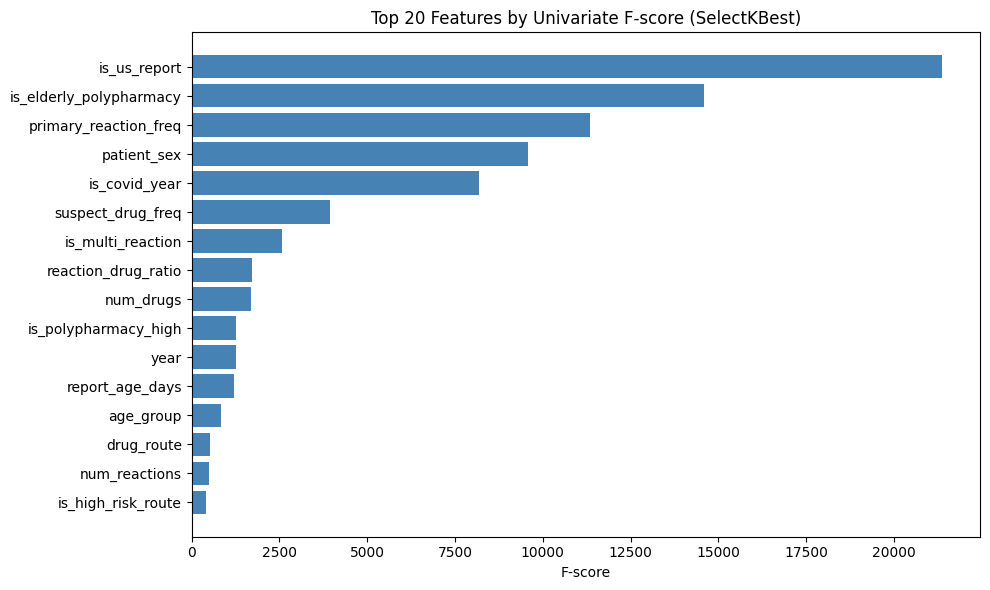


Final feature set: 16 features retained out of 16 total


In [45]:
top20 = scores_df.head(20).sort_values('f_score')

plt.figure(figsize=(10, 6))
plt.barh(top20['feature'], top20['f_score'], color='steelblue')
plt.xlabel('F-score')
plt.title('Top 20 Features by Univariate F-score (SelectKBest)')
plt.tight_layout()
plt.show()

print(f"\nFinal feature set: {X_train_sel.shape[1]} features retained out of {X_train_bal.shape[1]} total")


# VIII. Classification Modeling

We train and evaluate multiple classifiers on the SMOTE-balanced, feature-selected training data
(`X_train_sel`) and evaluate each against the real-distribution test set (`X_test_sel`).

Models included:
1. Logistic Regression (linear baseline)
2. Decision Tree
3. Random Forest
4. XGBoost
5. LightGBM

Evaluation metrics: Accuracy, Precision, Recall, F1-score, ROC-AUC


## Helper: Evaluation Function

In [46]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report
)

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_te)[:, 1]
    else:
        y_prob = model.decision_function(X_te)

    acc   = accuracy_score(y_te, y_pred)
    prec  = precision_score(y_te, y_pred, zero_division=0)
    rec   = recall_score(y_te, y_pred, zero_division=0)
    f1    = f1_score(y_te, y_pred, zero_division=0)
    auc   = roc_auc_score(y_te, y_prob)

    print(f"{'=' * 50}")
    print(f"Model: {name}")
    print(f"{'=' * 50}")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1-score:  {f1:.4f}")
    print(f"  ROC-AUC:   {auc:.4f}")
    print()
    print(classification_report(y_te, y_pred, target_names=['Not Fatal', 'Fatal']))

    return {
        'Model': name, 'Accuracy': acc, 'Precision': prec,
        'Recall': rec, 'F1': f1, 'ROC-AUC': auc,
        'fitted_model': model, 'y_prob': y_prob, 'y_pred': y_pred
    }

## Model 1 - Logistic Regression (Baseline)

A linear baseline that provides a reference point for more complex models.
`max_iter=1000` ensures convergence on the scaled feature space.

In [47]:
results = []

from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
res = evaluate_model('Logistic Regression', lr, X_train_sel, y_train_bal, X_test_sel, y_test)
results.append({k: v for k, v in res.items() if k not in ['fitted_model', 'y_prob', 'y_pred']})

Model: Logistic Regression
  Accuracy:  0.6343
  Precision: 0.1630
  Recall:    0.6184
  F1-score:  0.2580
  ROC-AUC:   0.6764

              precision    recall  f1-score   support

   Not Fatal       0.94      0.64      0.76     94740
       Fatal       0.16      0.62      0.26     10860

    accuracy                           0.63    105600
   macro avg       0.55      0.63      0.51    105600
weighted avg       0.86      0.63      0.71    105600



## Model 2 - Decision Tree

In [48]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=10, min_samples_leaf=50, random_state=42)
res = evaluate_model('Decision Tree', dt, X_train_sel, y_train_bal, X_test_sel, y_test)
results.append({k: v for k, v in res.items() if k not in ['fitted_model', 'y_prob', 'y_pred']})

Model: Decision Tree
  Accuracy:  0.6396
  Precision: 0.1889
  Recall:    0.7603
  F1-score:  0.3026
  ROC-AUC:   0.7703

              precision    recall  f1-score   support

   Not Fatal       0.96      0.63      0.76     94740
       Fatal       0.19      0.76      0.30     10860

    accuracy                           0.64    105600
   macro avg       0.57      0.69      0.53    105600
weighted avg       0.88      0.64      0.71    105600



## Model 3 - Random Forest

In [49]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=20,
    n_jobs=-1,
    random_state=42
)
res_rf = evaluate_model('Random Forest', rf, X_train_sel, y_train_bal, X_test_sel, y_test)
results.append({k: v for k, v in res_rf.items() if k not in ['fitted_model', 'y_prob', 'y_pred']})

Model: Random Forest
  Accuracy:  0.8125
  Precision: 0.3054
  Recall:    0.6457
  F1-score:  0.4147
  ROC-AUC:   0.8414

              precision    recall  f1-score   support

   Not Fatal       0.95      0.83      0.89     94740
       Fatal       0.31      0.65      0.41     10860

    accuracy                           0.81    105600
   macro avg       0.63      0.74      0.65    105600
weighted avg       0.89      0.81      0.84    105600



## Model 4 - XGBoost

In [50]:
import re

In [51]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

X_train_sel.columns = [re.sub(r'[\[\]<]', '_', str(col)) for col in X_train_sel.columns]
X_test_sel.columns = [re.sub(r'[\[\]<]', '_', str(col)) for col in X_test_sel.columns]

res_xgb = evaluate_model('XGBoost', xgb, X_train_sel, y_train_bal, X_test_sel, y_test)
results.append({k: v for k, v in res_xgb.items() if k not in ['fitted_model', 'y_prob', 'y_pred']})

Model: XGBoost
  Accuracy:  0.9010
  Precision: 0.5251
  Recall:    0.3885
  F1-score:  0.4466
  ROC-AUC:   0.8380

              precision    recall  f1-score   support

   Not Fatal       0.93      0.96      0.95     94740
       Fatal       0.53      0.39      0.45     10860

    accuracy                           0.90    105600
   macro avg       0.73      0.67      0.70    105600
weighted avg       0.89      0.90      0.89    105600



## Model 5 - LightGBM

In [52]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
def clean_column_names(df):
    df.columns = [re.sub(r'[^A-Za-z0-9_]+', '_', str(col)) for col in df.columns]
    df.columns = [re.sub(r'_+', '_', col).strip('_') for col in df.columns]
    return df

X_train_sel = clean_column_names(X_train_sel)
X_test_sel  = clean_column_names(X_test_sel)

res_lgbm = evaluate_model('LightGBM', lgbm, X_train_sel, y_train_bal, X_test_sel, y_test)
results.append({k: v for k, v in res_lgbm.items() if k not in ['fitted_model', 'y_prob', 'y_pred']})

Model: LightGBM
  Accuracy:  0.8981
  Precision: 0.5061
  Recall:    0.3755
  F1-score:  0.4311
  ROC-AUC:   0.8212

              precision    recall  f1-score   support

   Not Fatal       0.93      0.96      0.94     94740
       Fatal       0.51      0.38      0.43     10860

    accuracy                           0.90    105600
   macro avg       0.72      0.67      0.69    105600
weighted avg       0.89      0.90      0.89    105600



# IX. Model Comparison

In [53]:
results_df = pd.DataFrame(results).set_index('Model')
results_df = results_df.sort_values('ROC-AUC', ascending=False)
results_df = results_df.round(4)

print("Model Comparison (sorted by ROC-AUC):")
print()
print(results_df.to_string())

Model Comparison (sorted by ROC-AUC):

                     Accuracy  Precision  Recall      F1  ROC-AUC
Model                                                            
Random Forest          0.8125     0.3054  0.6457  0.4147   0.8414
XGBoost                0.9010     0.5251  0.3885  0.4466   0.8380
LightGBM               0.8981     0.5061  0.3755  0.4311   0.8212
Decision Tree          0.6396     0.1889  0.7603  0.3026   0.7703
Logistic Regression    0.6343     0.1630  0.6184  0.2580   0.6764


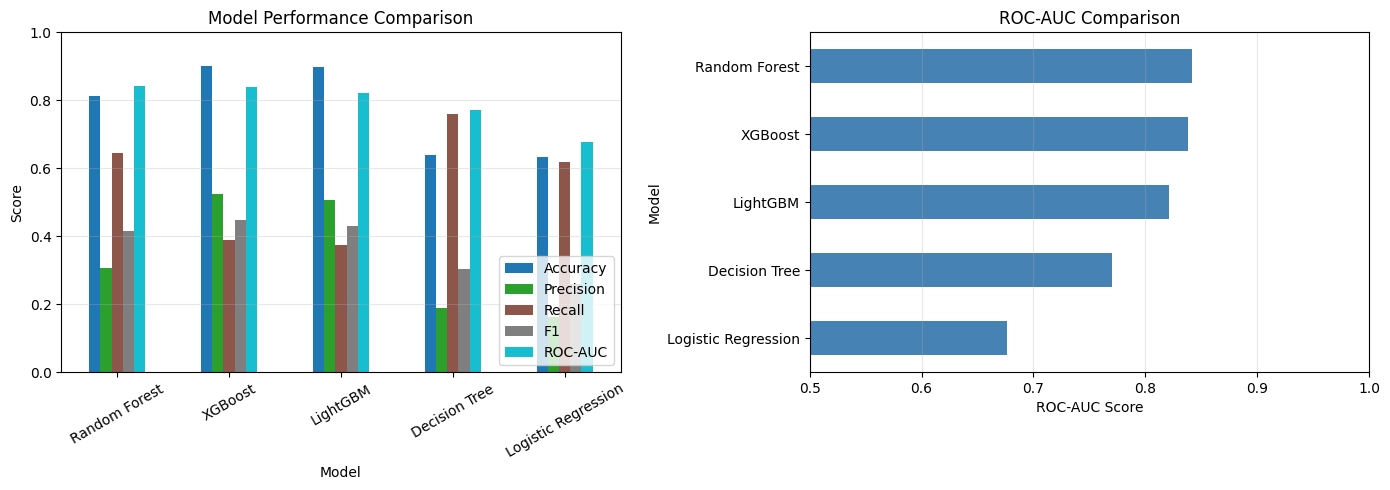

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
results_plot = results_df[metrics]

results_plot.plot(kind='bar', ax=axes[0], rot=30, colormap='tab10')
axes[0].set_title('Model Performance Comparison')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1)
axes[0].legend(loc='lower right')
axes[0].grid(axis='y', alpha=0.3)

results_df['ROC-AUC'].sort_values().plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('ROC-AUC Comparison')
axes[1].set_xlabel('ROC-AUC Score')
axes[1].set_xlim(0.5, 1.0)
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# X. Best Model Deep Dive

We select the best model by ROC-AUC and visualize its confusion matrix,
ROC curve, and feature importances.

In [55]:
best_index = results_df['ROC-AUC'].idxmax()
best_name = results_df.loc[best_index, 'Model'] if 'Model' in results_df.columns else best_index
print(f"Best model by ROC-AUC: {best_name}")

model_map = {
    'Logistic Regression': lr,
    'Decision Tree': dt,
    'Random Forest': res_rf['fitted_model'],
    'XGBoost': res_xgb['fitted_model'],
    'LightGBM': res_lgbm['fitted_model'],
}

best_model = model_map[best_name]

if hasattr(best_model, 'feature_names_in_'):
    X_test_sel.columns = best_model.feature_names_in_
elif hasattr(best_model, 'get_booster'): 
    X_test_sel.columns = best_model.get_booster().feature_names

y_pred_best = best_model.predict(X_test_sel)
y_prob_best = best_model.predict_proba(X_test_sel)[:, 1]

Best model by ROC-AUC: Random Forest


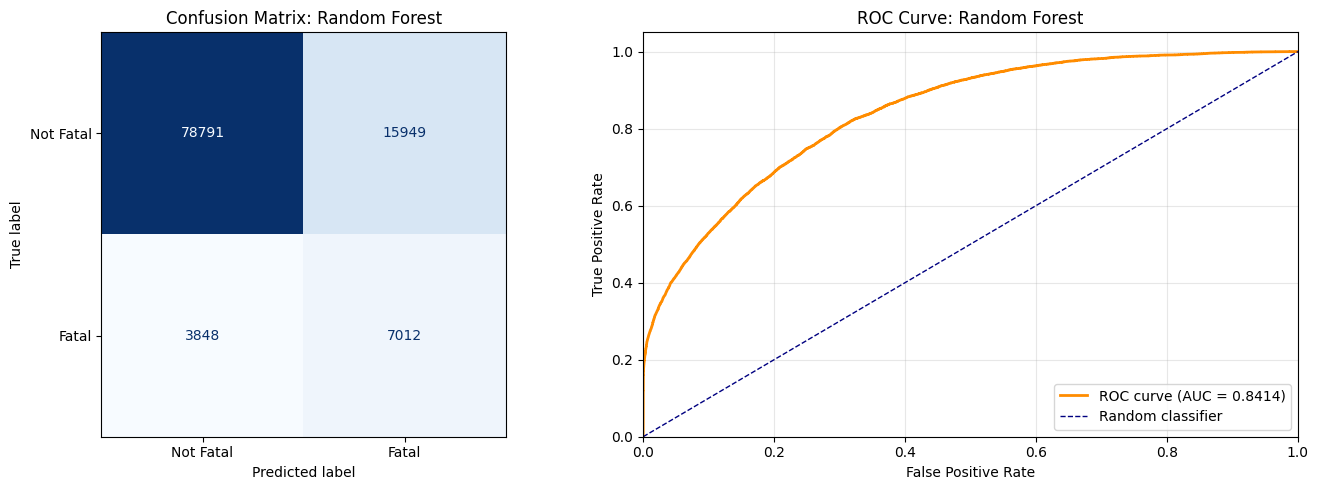

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Fatal', 'Fatal'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Confusion Matrix: {best_name}')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_best)
auc_score = roc_auc_score(y_test, y_prob_best)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Random classifier')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title(f'ROC Curve: {best_name}')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

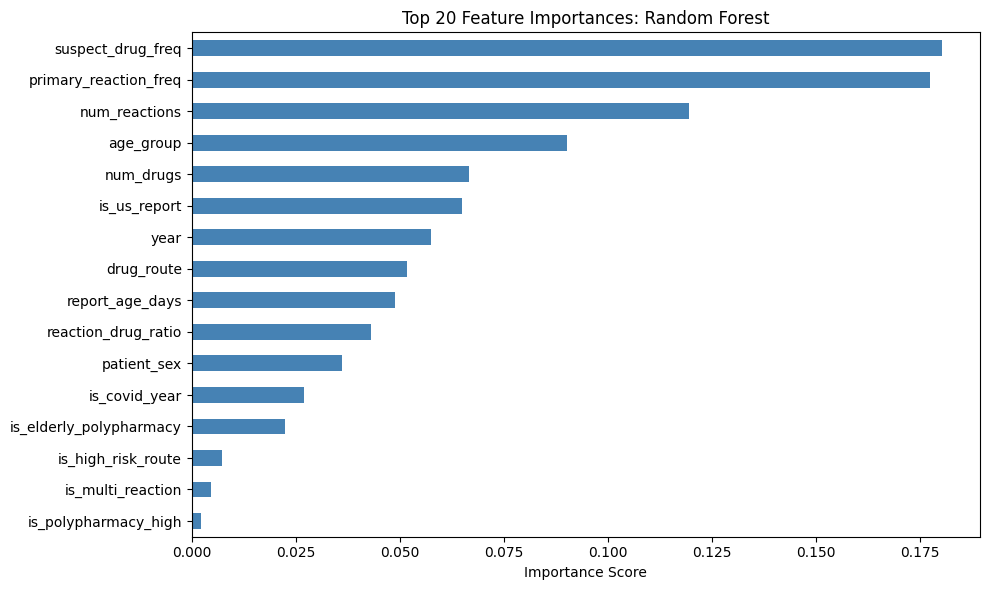

Top 20 most important features:
suspect_drug_freq          0.18035
primary_reaction_freq      0.17740
num_reactions              0.11950
age_group                  0.09017
num_drugs                  0.06652
is_us_report               0.06491
year                       0.05747
drug_route                 0.05169
report_age_days            0.04888
reaction_drug_ratio        0.04318
patient_sex                0.03613
is_covid_year              0.02698
is_elderly_polypharmacy    0.02246
is_high_risk_route         0.00741
is_multi_reaction          0.00457
is_polypharmacy_high       0.00237


In [57]:
# Feature Importances (for tree-based models)
if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(
        best_model.feature_importances_,
        index=X_test_sel.columns
    ).sort_values(ascending=False).head(20)

    plt.figure(figsize=(10, 6))
    importances.sort_values().plot(kind='barh', color='steelblue')
    plt.title(f'Top 20 Feature Importances: {best_name}')
    plt.xlabel('Importance Score')
    plt.tight_layout()
    plt.show()

    print("Top 20 most important features:")
    print(importances.round(5).to_string())
else:
    print(f"{best_name} does not expose feature_importances_. Skipping importance plot.")

# XI. Interpretation

In this section, we interpret the results of each model and explain what the numbers actually mean in the context of predicting fatal drug adverse events.

## Model Results Summary

| Model | Accuracy | Precision | Recall | F1-score | ROC-AUC |
|---|---|---|---|---|---|
| Random Forest | 0.8125 | 0.3054 | 0.6457 | 0.4147 | 0.8414 |
| XGBoost | 0.9010 | 0.5251 | 0.3885 | 0.4466 | 0.8380 |
| LightGBM | 0.8981 | 0.5061 | 0.3755 | 0.4311 | 0.8212 |
| Decision Tree | 0.6396 | 0.1889 | 0.7603 | 0.3026 | 0.7703 |
| Logistic Regression | 0.6343 | 0.1630 | 0.6184 | 0.2580 | 0.6764 |

> Models are sorted by ROC-AUC score, which is our primary evaluation metric since the dataset is imbalanced (only 10.3% of cases are fatal).

#What the metrics mean?
**Accuracy** → Overall **percentage** of correct predictions.

**Precision** → Of the cases predicted as **fatal**, how many were actually fatal?

**Recall** → Of all actual fatal cases, how many the model successfully found?

**F1-score** → Balance between precision and recall

**ROC-AUC** → Overall ability to separate fatal vs non-fatal cases across thresholds.


## Model 1: Logistic Regression (Baseline)

**Accuracy: 0.6343 | Precision: 0.1630 | Recall: 0.6184 | F1: 0.2580 | ROC-AUC: 0.6764**

Logistic Regression is our linear baseline — the simplest model in the pipeline, and the weakest performer overall.

The accuracy of **(0.6343)** looks acceptable at first glance, but it is misleading here. Because only **10.3%** of cases are actually fatal, a model that always predicted "Not Fatal" would score around **90%** accuracy without learning anything useful. So accuracy alone is not a reliable measure for this problem

The recall of **(0.6184)** means the model managed to catch about 62% of the real fatal cases. The problem is precision: at only **(0.1630)**, it means that out of every **10** cases it flagged as fatal, roughly **8** were actually not fatal. The model casts a very wide net and generates a lot of false alarms.

The ROC-AUC of **(0.6764)** tells us that while the model has some ability to rank cases by risk, it is far from reliable. This makes sense because the relationship between features and fatality is not strictly linear.

In short: this model works as a baseline, but it is too imprecise for a task as sensitive as predicting fatalities.


## Model 2: Decision Tree

**Accuracy: 0.6396 | Precision: 0.1889 | Recall: 0.7603 | F1: 0.3026 | ROC-AUC: 0.7703**

The Decision Tree is a step up from Logistic Regression, particularly in recall.

The ROC-AUC jumped to 0.7703, meaning the model is now meaningfully better than random at ranking fatal cases higher than non-fatal ones. Recall improved strongly to 0.7603 — the model now catches about 76% of actual fatalities, the highest recall of all five models. Precision moved slightly up to 0.1889, so roughly 1 in 5 flagged cases is genuinely fatal. That is still a lot of false alarms, but the model is very sensitive to catching real deaths.

The Decision Tree achieves this by learning if-then rules directly from the data — for example, it can detect patterns like "if the patient is elderly AND on 6+ drugs AND the drug is a TNF blocker, the risk goes up." Logistic Regression cannot do this without manual feature engineering.

The limitation here is that a single Decision Tree tends to overfit and be noisy. It picks up on specific patterns in the training data that may not generalise well. This is why ensemble methods like Random Forest and XGBoost, which build many trees together, tend to perform better.


## Model 3: Random Forest (Best Model)

**Accuracy: 0.8125 | Precision: 0.3054 | Recall: 0.6457 | F1: 0.4147 | ROC-AUC: 0.8414**

Random Forest is the best-performing model in this project, ranked first by ROC-AUC (0.8414).

The ROC-AUC reached 0.8414, the accuracy climbed to 0.8125, and the F1-score rose to 0.4147. Precision improved to 0.3054, meaning roughly 1 in 3 fatality predictions is now correct. Recall held at 0.6457 — the model catches about 65% of real fatal cases while dramatically reducing false alarms compared to the simpler models.

The reason for this improvement is the "wisdom of the crowd" principle behind Random Forest. Instead of relying on one decision tree, it trains hundreds of trees simultaneously, each on a slightly different random subset of the data and features. The final prediction is a vote across all trees, which smooths out the noise and overfitting that hurt the single Decision Tree.

Random Forest offers the best overall balance in this project: strong ROC-AUC, solid recall, and meaningfully better precision than the two simpler models.


## Model 4: XGBoost

**Accuracy: 0.9010 | Precision: 0.5251 | Recall: 0.3885 | F1: 0.4466 | ROC-AUC: 0.8380**

XGBoost is the second-best model by ROC-AUC (0.8380), very close to Random Forest's 0.8414.

The accuracy is high at 0.9010, and precision reaches 0.5251 — meaning more than 1 in 2 cases flagged as fatal are genuinely fatal. This is a significant improvement in reliability over the simpler models.

The trade-off is recall, which drops to 0.3885. The model is now more conservative — it only raises an alert when it is fairly confident, so it misses more fatal cases than Random Forest does. In a screening context where catching as many fatal cases as possible matters, this is an important consideration.

XGBoost works by building trees sequentially, where each new tree focuses specifically on the cases the previous trees got wrong. This iterative error-correction process is what drives its high precision. It also handles the imbalanced nature of this dataset well — it keeps refining its understanding of the rare fatal class rather than treating all mistakes equally.


## Model 5: LightGBM

**Accuracy: 0.8981 | Precision: 0.5061 | Recall: 0.3755 | F1: 0.4311 | ROC-AUC: 0.8212**

LightGBM ranks third by ROC-AUC (0.8212), behind both Random Forest and XGBoost.

Its accuracy (0.8981) and precision (0.5061) are strong — about 1 in 2 fatality predictions is correct. However, recall is the lowest of all five models at 0.3755, meaning it misses more than 62% of actual fatal cases. Its F1-score of 0.4311 is also the lowest among the top three models.

LightGBM is designed to be faster and more memory-efficient than XGBoost, especially on large datasets. It uses a leaf-wise tree growth strategy (growing the most useful leaf first) rather than the level-wise strategy of XGBoost, which allows it to find more complex patterns with fewer trees. With 528,000 rows, this speed advantage was noticeable during training.

In this run, LightGBM did not match the performance of XGBoost or Random Forest on the key metrics. The gap in ROC-AUC (0.8212 vs. 0.8414) is meaningful and suggests that further hyperparameter tuning could potentially close the distance.


## Overall Interpretation

Looking across all five models, a few clear patterns emerge.

**Random Forest is the overall winner:** With the highest ROC-AUC (0.8414), Random Forest delivers the best separation between fatal and non-fatal cases. It also maintains strong recall (0.6457) while achieving meaningfully better precision (0.3054) than the simpler models. XGBoost comes in a close second (ROC-AUC: 0.8380) with higher precision but lower recall.

**Accuracy vs. usefulness:** The first two models (Logistic Regression and Decision Tree) had decent recall but low precision, meaning they flagged too many non-fatal cases as fatal. The last two (XGBoost and LightGBM) reversed this — higher precision but lower recall. Random Forest sits in the middle and strikes the best overall balance. None of the models achieve both high precision and high recall simultaneously, which reflects the fundamental difficulty of the problem: fatal cases are rare (10.3%) and share many characteristics with non-fatal ones.

**ROC-AUC is the right metric here:** Since the dataset is heavily imbalanced, ROC-AUC is the most honest measure of model quality. It measures how well the model can rank fatal cases above non-fatal ones, regardless of the threshold used. Random Forest's 0.8414 is the strongest result for this real-world imbalanced medical dataset.

**The 2020 COVID effect was real:** The is_covid_year flag was consistently important across models. Fatal adverse event rates were nearly double in 2020 (17.73%) compared to other years (9.54%), reflecting the combined effect of experimental treatments, overwhelmed healthcare systems, and a higher-risk patient population during the pandemic.

**Where the models consistently struggle:** All five models have a hard time with borderline cases — situations where the predicted probability of a fatal event falls between 30% and 60%. These cases are genuinely ambiguous because the available features do not provide a strong enough signal.

The biggest missing piece is patient weight. Since weight data was missing in 72% of the reports, it had to be excluded entirely. Body weight is critical for determining safe drug doses and toxicity thresholds — its absence is the single largest gap in the feature space.


# XII. Conclusion

## Summary of What We Did

This project built an end-to-end binary classification pipeline to predict fatal drug adverse events using the FDA Adverse Event Reporting System (FAERS) dataset, covering reports from 2015 to 2026. The pipeline followed these main stages:

**EDA → Preprocessing → Feature Engineering → Encoding → Feature Selection → Modeling → Evaluation**

The target variable was is_fatal, which was positive in 10.3% of cases — making this a classic imbalanced classification problem.

## Main Takeaways

**1. Random Forest was the best model overall (ROC-AUC: 0.8414)**
It achieved the best balance between precision (0.3054) and recall (0.6457), with the highest ROC-AUC among all five models. XGBoost was a close second (ROC-AUC: 0.8380) and is a strong alternative when higher precision is preferred over recall.

**2. SMOTE was essential for handling class imbalance**
The training set had only 10.3% fatal cases. SMOTE balanced it to 50/50 by generating synthetic fatal samples, which allowed all models to actually learn the minority class. Critically, SMOTE was applied only after the train/test split, so the test set remained at its real-world distribution.

**3. Removing leakage columns was the most important preprocessing step**
Columns like serious, serious_flags, is_hospitalized, and is_life_threat are definitionally linked to the target. Keeping them would have produced near-perfect scores that are completely fake. Removing them forced the models to learn from actual patient and drug features.

**4. Feature engineering added measurable signal**
All seven engineered features showed meaningful differences in fatal rates between their groups. For example, elderly polypharmacy patients had a fatal rate of 18.27% versus 9.20% for others — nearly double. The COVID year flag captured an 86% increase in fatal rate during 2020 compared to baseline years.


## Limitations

**Voluntary reporting bias:** FAERS is not a complete or random sample of all adverse events. Reports are filed voluntarily by healthcare providers, patients, and manufacturers. This means the dataset is biased toward cases that were noticed, documented, and submitted — and US cases are heavily over-represented (60% of the dataset).

**Missing patient weight (72%):** Body weight is one of the most important factors in determining drug dosage and toxicity. Because it was missing in nearly three-quarters of records, it had to be excluded entirely. This is the single largest gap in the feature space.

**Artificial annual stratification:** The dataset contains exactly 48,000 records per year, which is clearly artificial. This means it does not reflect the actual reporting volume trends in FAERS, and any temporal patterns (other than the COVID spike) may be distorted.

**Label noise:** Fatality labels in FAERS are based on the reporter's assessment, there are not any death certificate records. Some fatal outcomes may have been caused by the underlying disease rather than the drug, and some cases may be incorrectly labeled in either direction.